In [45]:
import uproot, pandas as pd, numpy as np
from pathlib import Path

# ---- Configuration --------------------------------------------------------
BASE_DIR  = Path("PPSSP_2026/1l2tau/run2")   # 1 lepton + 2 taus, Run 2
TREE_NAME = "AnalysisMiniTree"
RUN       = 2

# Preselection cuts for the 1L2Tau channel (see README)
PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# --- Feature selection policy ---------------------------------------------
# Load generously and let XGBoost prune via importance, BUT never let these
# branches enter as features (they poison the training / leak the label):
#   - weights & scale/fake factors  -> differ systematically signal vs bkg
#   - dsid / eventNumber            -> sample/event identifiers (label in disguise)
#   - *truth* / isTrue* / *fake*    -> generator info, absent in real data
#   - anti-tau bookkeeping          -> fake-region definition, process-dependent
#   - preselection constants        -> n_b_jet==0 always; pass1l2tau==1 always

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti", "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT  = {"n_b_jet", "pass1l2tau", "hhml_subchannelflavor", "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans", "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig"}
BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}

def is_feature(branch: str) -> bool:
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)

WEIGHT_PARTS = ["weight", "weights"]   # raw branches; w_phys = their product

files = {
    # process    : (filename, label)   1 = signal, 0 = background
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",         0),
}

# Build the feature list from branches COMMON to all files (robust against
# per-sample branch differences; a single-file probe could silently misalign)

common = None

for proc, (fname, _) in files.items():
    keys = set(uproot.open({str(BASE_DIR / fname): TREE_NAME}).keys())
    common = keys if common is None else common & keys
features = sorted(b for b in common if is_feature(b))

print(f"{len(features)} candidate features (common to all {len(files)} files, leakage-free)\n")

# ---- Extraction loop ------------------------------------------------------

dfs = []

for proc, (fname, label) in files.items():
    tree = uproot.open({str(BASE_DIR / fname): TREE_NAME})
    df = tree.arrays(features + WEIGHT_PARTS, cut=PRESELECTION, library="pd")

    """
    'weight'       = sigma*L/sum_w_gen, per DSID+campaign (raw branch, untouched)
    'weight_final' = generator event weight, Sherpa NLO -> negatives (raw branch, untouched)
    'w_phys'       = physical event weight -> use for training & yields
    """

    df["w_phys"]  = df["weight"] * df["weights"]
    df["label"]   = label   # 1 = signal, 0 = background
    df["process"] = proc    # keep track of the originating process
    df["run"]     = RUN
    dfs.append(df)
    print(f"{proc:12s}: {len(df):>8d} events after preselection")

data = pd.concat(dfs, ignore_index=True)

# ---- Post-concat cleaning --------------------------------------------------
# 1) Constant / empty features (zero variance, all-NaN or all-sentinel) -> drop

nun = data[features].nunique()
const = nun[nun <= 1].index.tolist()
features = [f for f in features if f not in const]
data = data.drop(columns=const)
print(f"\nDropped {len(const)} constant/empty features:\n  {sorted(const)}")

# 2) Sentinel values (e.g. -999) -> NaN; XGBoost routes NaNs natively.
#    Safe threshold here: all legit features are > -100 (eta, phi, pdg, charge).

for f in features:
    m = data[f] < -100
    if m.any():
        print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
        data[f] = data[f].mask(m)

print(f"\n{len(features)} final features")
print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | background = {(data.label==0).sum()}")
print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
data.head()


87 candidate features (common to all 10 files, leakage-free)

signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection

Dropped 19 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode', 'tau2_passOR']

68 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 |

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_eta,tau2_nprong,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,486197.28125,437935.43750,350626.937500,42837.089844,91098.921875,44471.410156,77389.632812,91956.718750,12270.166016,2.849011,...,0.794897,1,-3.045134,22102.740234,0.00125,-0.028450,-0.000036,1,signal_ggF,2
1,233307.37500,192779.18750,92852.828125,31019.406250,71547.601562,68906.953125,35689.703125,32890.671875,20957.582031,2.693458,...,2.437175,1,1.528327,30261.955078,0.00125,0.054811,0.000069,1,signal_ggF,2
2,399998.12500,345424.46875,107697.429688,164906.187500,219479.843750,72820.843750,127177.953125,97451.046875,33988.949219,0.399682,...,0.301610,1,0.593764,33664.312500,0.00125,0.029853,0.000037,1,signal_ggF,2
3,344867.65625,249412.12500,165593.328125,21953.849609,117409.382812,61864.949219,36656.707031,111334.617188,18972.347656,2.708711,...,1.256151,1,0.694036,21605.847656,0.00125,0.030944,0.000039,1,signal_ggF,2
4,326392.68750,270753.15625,128916.000000,71331.773438,126971.281250,70505.390625,129401.234375,129401.234375,55308.082031,2.955379,...,-0.066556,1,-1.724129,31729.716797,0.00125,0.032416,0.000041,1,signal_ggF,2


In [40]:
print(data.shape)

(690684, 80)


In [46]:
from sklearn.model_selection import train_test_split

# 80 / 20 train-validation split for Run 2, keeping the signal/background balance
train_df, val_df = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=data["label"],
)

X_train = train_df[features]
y_train = train_df["label"]
w_train = train_df["w_phys"]

X_val = val_df[features]
y_val = val_df["label"]
w_val = val_df["w_phys"]

print(f"Train: {len(train_df)} events | signal = {(y_train==1).sum()} | background = {(y_train==0).sum()}")
print(f"Val:   {len(val_df)} events | signal = {(y_val==1).sum()} | background = {(y_val==0).sum()}")


Train: 552547 events | signal = 70971 | background = 481576
Val:   138137 events | signal = 17743 | background = 120394


In [ ]:
# ---- Persist the train/val split to ROOT files (Run 2) ---------------------
# Lets us reload this exact preprocessed split later without rerunning
# extraction, cleaning and train_test_split from scratch.

SPLIT_DIR = BASE_DIR / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_ROOT = SPLIT_DIR / "train.root"
VAL_ROOT   = SPLIT_DIR / "val.root"

with uproot.recreate(TRAIN_ROOT) as f:
    f["tree"] = train_df.reset_index(drop=True)

with uproot.recreate(VAL_ROOT) as f:
    f["tree"] = val_df.reset_index(drop=True)

print(f"Wrote {len(train_df)} training events   -> {TRAIN_ROOT}")
print(f"Wrote {len(val_df)} validation events -> {VAL_ROOT}")

# --- Round-trip check + reload pattern for later use -------------------------
train_df_check = uproot.open({str(TRAIN_ROOT): "tree"}).arrays(library="pd")
val_df_check   = uproot.open({str(VAL_ROOT): "tree"}).arrays(library="pd")
assert len(train_df_check) == len(train_df) and len(val_df_check) == len(val_df)

print("Round-trip OK - reload later with:")
print('  train_df = uproot.open({str(TRAIN_ROOT): "tree"}).arrays(library="pd")')
print('  val_df   = uproot.open({str(VAL_ROOT): "tree"}).arrays(library="pd")')

Wrote 552547 training events   -> PPSSP_2026/1l2tau/run2/splits/train.root
Wrote 138137 validation events -> PPSSP_2026/1l2tau/run2/splits/val.root
Round-trip OK - reload later with:
  train_df = uproot.open({str(TRAIN_ROOT): "tree"}).arrays(library="pd")
  val_df   = uproot.open({str(VAL_ROOT): "tree"}).arrays(library="pd")


## XGBoost

In [47]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# --- Training weights -------------------------------------------------------
# 1) w_phys has negatives (Sherpa NLO). Negative sample_weights corrupt the
#    boosting gradients, so for TRAINING we use |w_phys| (yields keep the sign).

# 2) Class balance: physically sig/bkg = 1.8/11467 -> the model would learn
#    "everything is background". Rescale signal so both classes have equal
#    total weight.

# 3) Normalize mean weight to 1 so min_child_weight etc. behave like event counts.


w_fit = np.abs(w_train.to_numpy())

sum_sig, sum_bkg = w_fit[y_train == 1].sum(), w_fit[y_train == 0].sum()

w_fit[y_train == 1] *= sum_bkg / sum_sig

w_fit *= len(w_fit) / w_fit.sum()

w_val_fit = np.abs(w_val.to_numpy())   # for the weighted validation AUC

print(f"signal weight scale factor: {sum_bkg/sum_sig:.1f}")

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    n_jobs=1,
    random_state=42,
)

model.fit(
    X_train, y_train,
    sample_weight=w_fit,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[w_val_fit],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")
auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1], sample_weight=np.abs(w_train))
auc_val   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1],   sample_weight=w_val_fit)
print(f"Weighted AUC: train = {auc_train:.4f} | validation = {auc_val:.4f}")


signal weight scale factor: 8844.6
[0]	validation_0-auc:0.90543
[50]	validation_0-auc:0.93481
[100]	validation_0-auc:0.93802
[150]	validation_0-auc:0.94182
[200]	validation_0-auc:0.94264
[250]	validation_0-auc:0.94313
[300]	validation_0-auc:0.94300
[307]	validation_0-auc:0.94304

Best iteration: 277
Weighted AUC: train = 0.9713 | validation = 0.9432


Top 30 features by total gain:
               total_gain  gain_frac  weight
HT_tau      996372.250000   0.427930   388.0
dR_t1t2     132002.625000   0.056694   549.0
m_t1t2       84993.421875   0.036504   617.0
SumPt_t1t2   73092.132812   0.031392   462.0
met_sumet    72621.031250   0.031190   403.0
dR_l1j1      65834.210938   0.028275   397.0
HT           64133.742188   0.027545   289.0
tau1_pt      52989.207031   0.022758   258.0
m_l1j        50430.843750   0.021659   361.0
tau2_pt      45558.921875   0.019567   440.0
met_met      39784.007812   0.017087   404.0
m_ttl        28506.748047   0.012243   347.0
m_l1j1       25237.673828   0.010839   304.0
m_l1t        24313.533203   0.010442   334.0
dR_t1t2_l1   24184.748047   0.010387   344.0
HT_lepMET    22824.654297   0.009803   337.0
m_l1t1       21572.132812   0.009265   312.0
tau1_eta     21172.189453   0.009093   394.0
dR_l1j2      19314.996094   0.008296   308.0
dR_l1t       18982.156250   0.008153   294.0
tau2_eta     18634.07812

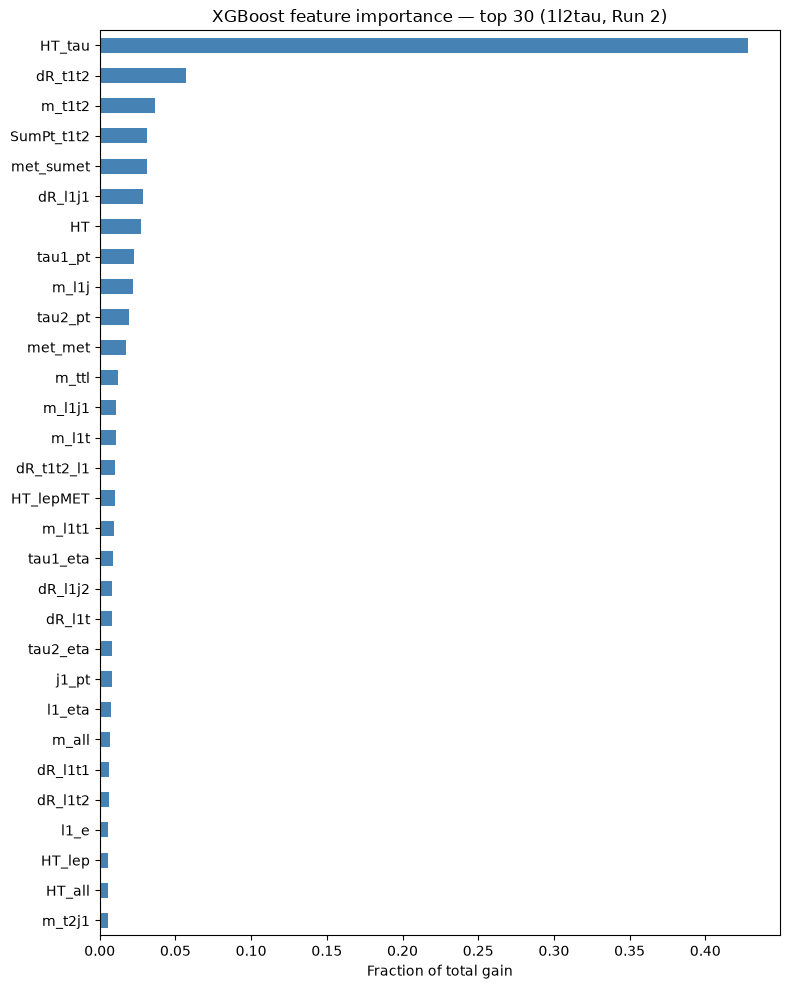

In [48]:
import matplotlib.pyplot as plt

# --- Feature importance ------------------------------------------------------
# total_gain = total loss reduction contributed by a feature (best for ranking).
booster = model.get_booster()

imp = pd.DataFrame({
    t: booster.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(features).fillna(0.0)

imp = imp.sort_values("total_gain", ascending=False)
imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()

print("Top 30 features by total gain:")
print(imp[["total_gain", "gain_frac", "weight"]].head(30).to_string())
print(f"\nFeatures never used in a split: {(imp['total_gain'] == 0).sum()} / {len(features)}")

TOP_N = 30

fig, ax = plt.subplots(figsize=(8, 10))

imp["gain_frac"].head(TOP_N)[::-1].plot.barh(ax=ax, color="steelblue")

ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance — top {TOP_N} (1l2tau, Run 2)")
plt.tight_layout()
plt.show()


Top 30 features by average gain:
                    gain  gain_share  weight
HT_tau       2567.969727    0.348874   388.0
dR_t1t2       240.441940    0.032665   549.0
tau2_charge   225.136154    0.030586    53.0
HT            221.916061    0.030149   289.0
tau1_pt       205.384521    0.027903   258.0
tau1_charge   199.900284    0.027158    47.0
pass_LTT      197.598267    0.026845    49.0
met_sumet     180.201065    0.024481   403.0
dR_l1j1       165.829254    0.022529   397.0
SumPt_t1t2    158.208084    0.021494   462.0
m_l1j         139.697632    0.018979   361.0
m_t1t2        137.752716    0.018715   617.0
tau2_pt       103.543007    0.014067   440.0
met_met        98.475266    0.013378   404.0
l1_charge      91.690964    0.012457    46.0
m_l1j1         83.018661    0.011279   304.0
m_ttl          82.152008    0.011161   347.0
tau2_nprong    82.090164    0.011152    71.0
m_l1t          72.795006    0.009890   334.0
dR_t1t2_l1     70.304497    0.009551   344.0
m_l1t1         69.1414

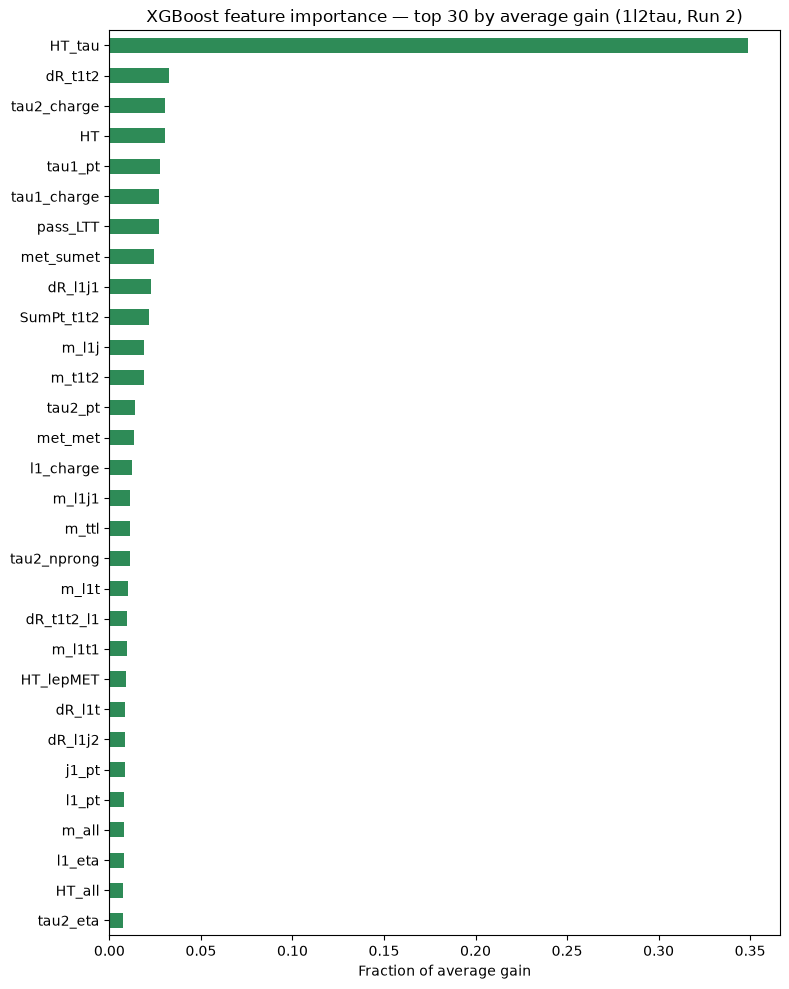

In [49]:
# --- Feature importance by average gain (check against total_gain ranking) --
# gain = average loss reduction per split on that feature (unlike total_gain,
# it is NOT inflated by how many times a feature is used).
imp_by_gain = imp.sort_values("gain", ascending=False).copy()
imp_by_gain["gain_share"] = imp_by_gain["gain"] / imp_by_gain["gain"].sum()

print("Top 30 features by average gain:")
print(imp_by_gain[["gain", "gain_share", "weight"]].head(30).to_string())

fig, ax = plt.subplots(figsize=(8, 10))

imp_by_gain["gain_share"].head(TOP_N)[::-1].plot.barh(ax=ax, color="seagreen")

ax.set_xlabel("Fraction of average gain")
ax.set_title(f"XGBoost feature importance — top {TOP_N} by average gain (1l2tau, Run 2)")
plt.tight_layout()
plt.show()


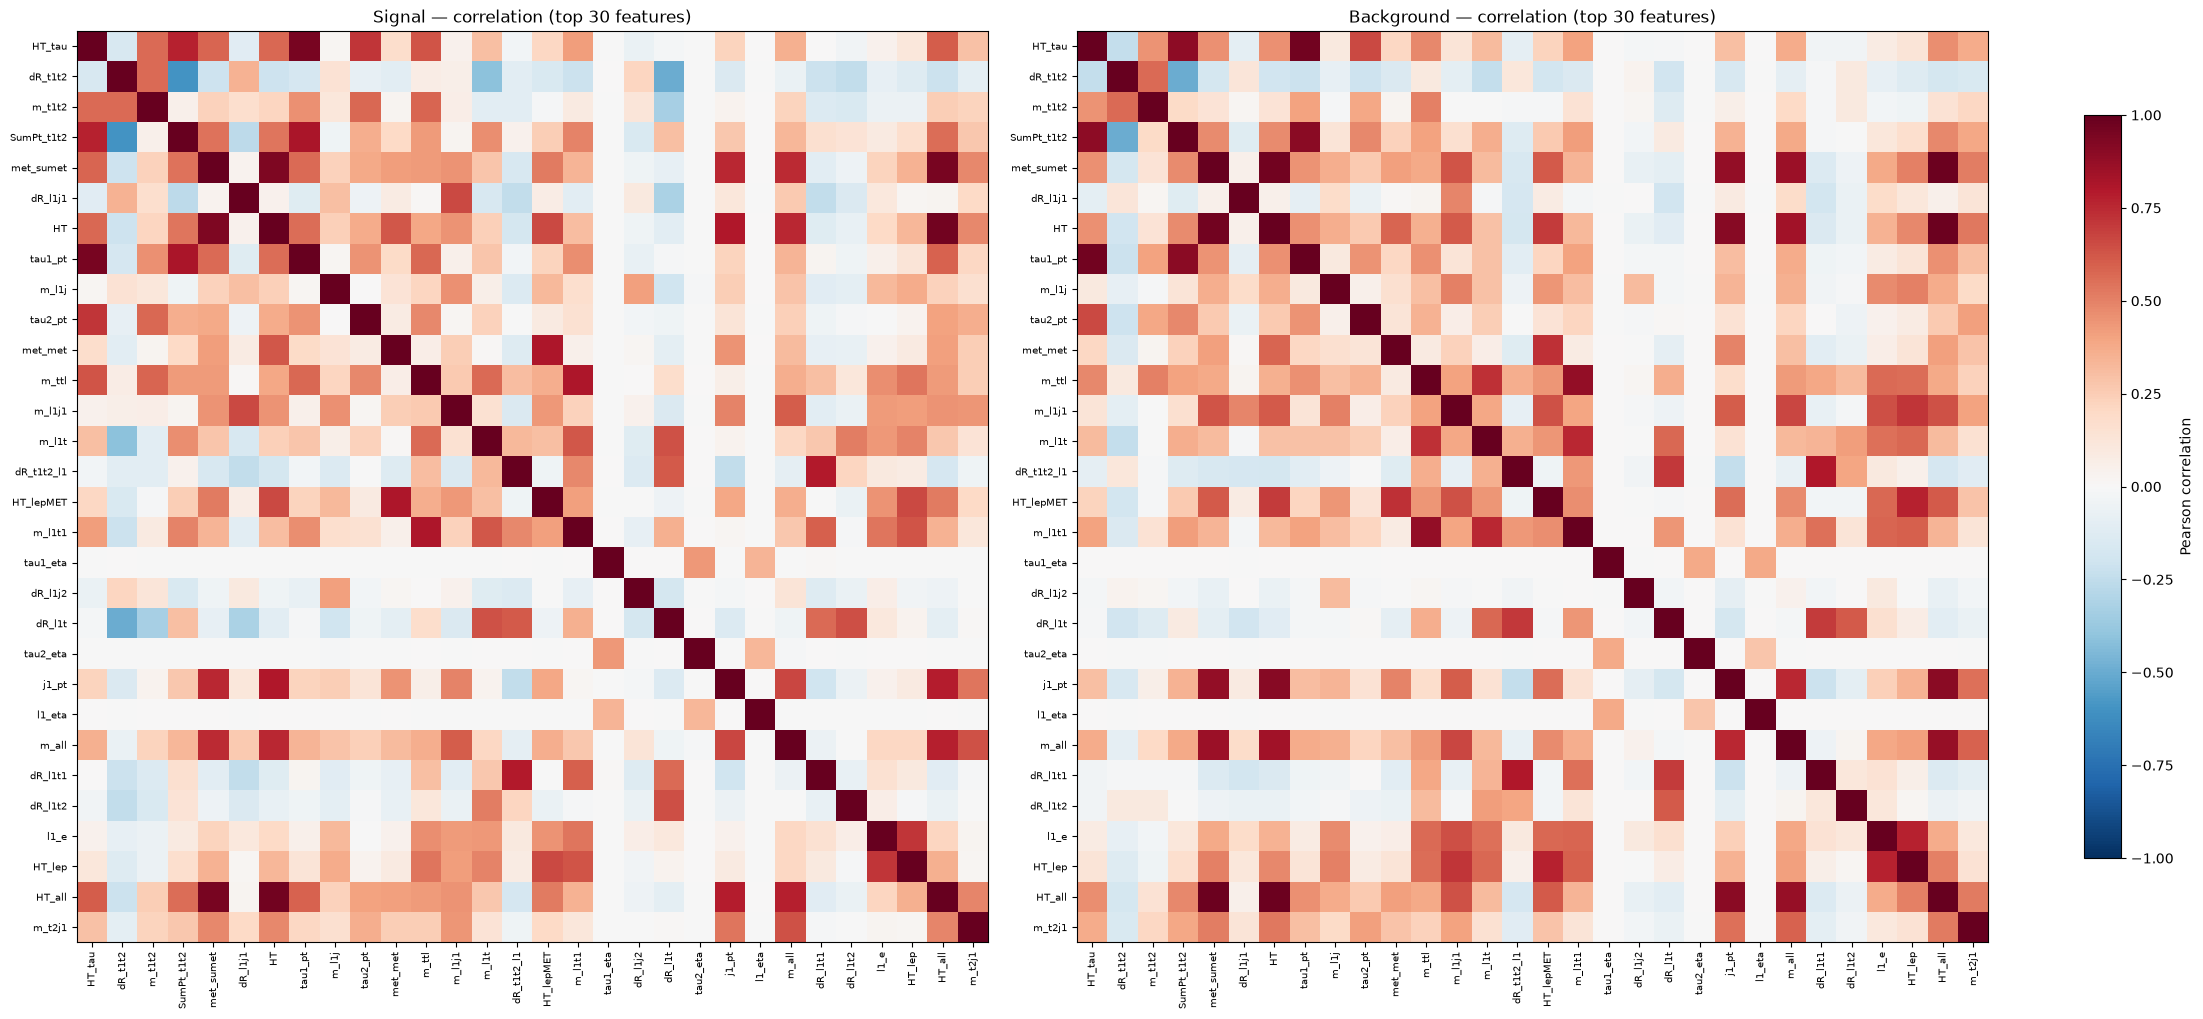

Pairs with |corr| > 0.50 (signal):
HT          HT_all        0.968501
met_sumet   HT_all        0.951155
HT_tau      tau1_pt       0.945766
met_sumet   HT            0.930010
SumPt_t1t2  tau1_pt       0.812904
met_met     HT_lepMET     0.810867
m_ttl       m_l1t1        0.805546
HT          j1_pt         0.797357
dR_t1t2_l1  dR_l1t1       0.794670
j1_pt       HT_all        0.787930
m_all       HT_all        0.775714
HT_tau      SumPt_t1t2    0.768862
met_sumet   j1_pt         0.755326
HT          m_all         0.750750
met_sumet   m_all         0.746627
HT_tau      tau2_pt       0.716004
l1_e        HT_lep        0.713783
j1_pt       m_all         0.664563
HT          HT_lepMET     0.663759
dR_l1j1     m_l1j1        0.660874
HT_lepMET   HT_lep        0.657064
dR_l1t      dR_l1t2       0.643508
m_all       m_t2j1        0.636611
m_l1t       dR_l1t        0.634959
m_l1t1      HT_lep        0.631298
HT_tau      m_ttl         0.626184
HT          met_met       0.621954
m_l1t       m_l1t1  

In [65]:
# --- Correlation of the top features ----------------------------------------
# Pearson correlation among the TOP_N most important features, separately for
# signal and background (correlations differ between the two by physics).

top_feats = imp.index[:TOP_N].tolist()

corr_sig = data.loc[data.label == 1, top_feats].corr()
corr_bkg = data.loc[data.label == 0, top_feats].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
for ax, corr, title in [(axes[0], corr_sig, "Signal"), (axes[1], corr_bkg, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=90, fontsize=7)
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats, fontsize=7)
    ax.set_title(f"{title} — correlation (top {TOP_N} features)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")

plt.show()

# Highly correlated pairs -> redundant, candidates to prune after importance

def top_pairs(corr, thr=0.50):
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corr_sig).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corr_bkg).to_string())


In [51]:
# --- Prune redundant (highly correlated) features down to N_KEEP -----------
# Walk the top_feats list in importance order (most important first). For each
# feature, check its correlation against every feature ALREADY kept (i.e. every
# more-important feature seen so far). If it's correlated > CORR_THRESH with
# any of them (in signal OR background), it's redundant -> drop it (it's the
# "second most important" of that pair, since the more important one is
# already kept). Stop once N_KEEP features have been kept.

CORR_THRESH = 0.75
N_KEEP = 20

# Conservative combination: a pair counts as redundant if EITHER regime shows
# near-degeneracy.
corr_max = corr_sig.abs().combine(corr_bkg.abs(), np.maximum)

kept, dropped = [], []
for feat in top_feats:
    redundant_with = next(
        (k for k in kept if corr_max.loc[feat, k] > CORR_THRESH), None
    )
    if redundant_with is None:
        kept.append(feat)
    else:
        dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
    if len(kept) == N_KEEP:
        break

if len(kept) < N_KEEP:
    print(f"WARNING: only {len(kept)}/{N_KEEP} survivors found within top_feats "
          f"({len(top_feats)} features) - raise TOP_N or lower CORR_THRESH.")

print(f"Kept {len(kept)} decorrelated features (most -> least important):")
for i, feat in enumerate(kept, 1):
    print(f"  {i:2d}. {feat}")

print(f"\nDropped {len(dropped)} redundant features (|corr| > {CORR_THRESH} with a more important feature):")
for feat, because_of, corr_val in dropped:
    print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

PRUNED_FEATURES = kept

Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. dR_t1t2
   3. m_t1t2
   4. met_sumet
   5. dR_l1j1
   6. m_l1j
   7. tau2_pt
   8. met_met
   9. m_ttl
  10. m_l1j1
  11. m_l1t
  12. dR_t1t2_l1
  13. tau1_eta
  14. dR_l1j2
  15. dR_l1t
  16. tau2_eta
  17. l1_eta
  18. dR_l1t2
  19. l1_e
  20. m_t2j1

Dropped 10 redundant features (|corr| > 0.75 with a more important feature):
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.895)
  HT              -> redundant with met_sumet       (|corr| = 0.965)
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.811)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.877)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.882)
  m_all           -> redundant with met_sumet       (|corr| = 0.859)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  HT_lep          -> redundant with l1_e 

## Run after cut

In [55]:
# --- Retrain baseline XGBoost using only the pruned top-20 features (Run 2) --
model_pruned = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    n_jobs=1,
    random_state=42,
)

model_pruned.fit(
    X_train[PRUNED_FEATURES], y_train,
    sample_weight=w_fit,
    eval_set=[(X_val[PRUNED_FEATURES], y_val)],
    sample_weight_eval_set=[w_val_fit],
    verbose=50,
)

print(f"\nBest iteration: {model_pruned.best_iteration}")
auc_train_pruned = roc_auc_score(y_train, model_pruned.predict_proba(X_train[PRUNED_FEATURES])[:, 1], sample_weight=np.abs(w_train))
auc_val_pruned   = roc_auc_score(y_val,   model_pruned.predict_proba(X_val[PRUNED_FEATURES])[:, 1],   sample_weight=w_val_fit)
print(f"Weighted AUC (pruned {len(PRUNED_FEATURES)} features): train = {auc_train_pruned:.4f} | validation = {auc_val_pruned:.4f}")
print(f"Comparison - full {len(features)}-feature baseline:    train = {auc_train:.4f} | validation = {auc_val:.4f}")

[0]	validation_0-auc:0.90316
[50]	validation_0-auc:0.93021
[100]	validation_0-auc:0.93340
[150]	validation_0-auc:0.93453
[200]	validation_0-auc:0.93505
[242]	validation_0-auc:0.93510

Best iteration: 212
Weighted AUC (pruned 20 features): train = 0.9565 | validation = 0.9352
Comparison - full 68-feature baseline:    train = 0.9713 | validation = 0.9432


Pruned model (20 features) - importance by total gain:
               total_gain  gain_frac  weight
HT_tau      847455.437500   0.406114   776.0
met_sumet   250926.500000   0.120248   759.0
dR_t1t2     188963.640625   0.090554  1034.0
tau2_pt     101163.890625   0.048479   726.0
m_t1t2       92522.703125   0.044338   878.0
dR_l1j1      81408.570312   0.039012   681.0
met_met      72332.578125   0.034663   801.0
dR_t1t2_l1   49987.023438   0.023955   806.0
m_l1j        47243.917969   0.022640   598.0
m_ttl        46015.625000   0.022051   691.0
m_l1j1       43669.988281   0.020927   531.0
dR_l1j2      36428.730469   0.017457   637.0
m_l1t        35296.984375   0.016915   639.0
tau1_eta     31982.843750   0.015327   697.0
l1_eta       29797.501953   0.014279   617.0
dR_l1t       28008.470703   0.013422   558.0
l1_e         27848.669922   0.013346   647.0
m_t2j1       27036.792969   0.012956   645.0
tau2_eta     26745.101562   0.012817   617.0
dR_l1t2      21909.416016   0.010499   506.0


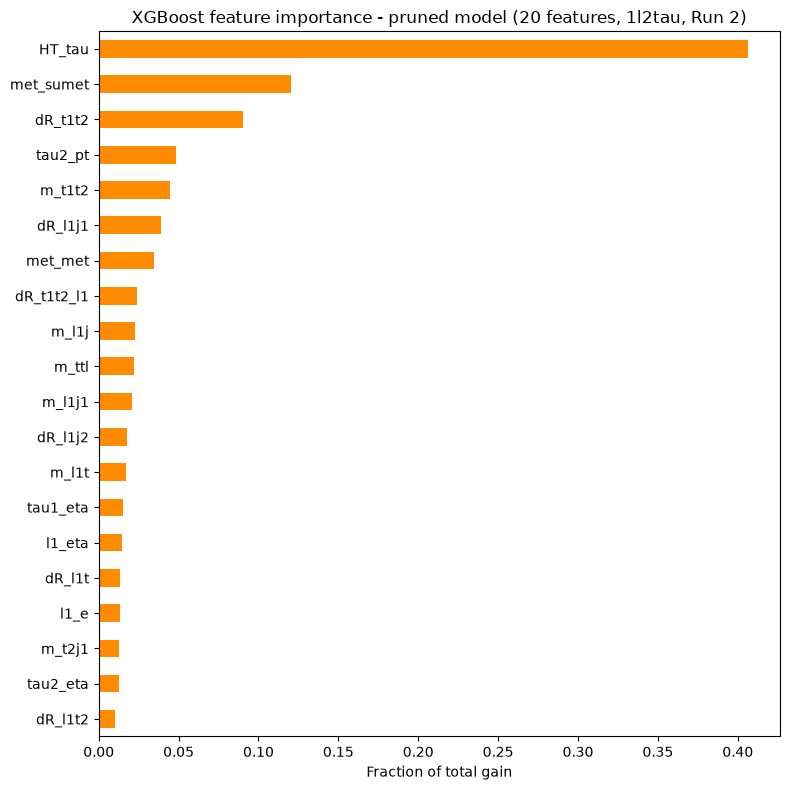

In [60]:
# --- Feature importance of the pruned model (Run 2) --------------------------
booster_pruned = model_pruned.get_booster()

imp_pruned = pd.DataFrame({
    t: booster_pruned.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(PRUNED_FEATURES).fillna(0.0)

imp_pruned = imp_pruned.sort_values("total_gain", ascending=False)
imp_pruned["gain_frac"] = imp_pruned["total_gain"] / imp_pruned["total_gain"].sum()

print("Pruned model (20 features) - importance by total gain:")
print(imp_pruned[["total_gain", "gain_frac", "weight"]].to_string())
print(f"\nFeatures never used in a split: {(imp_pruned['total_gain'] == 0).sum()} / {len(PRUNED_FEATURES)}")

fig, ax = plt.subplots(figsize=(8, 8))
imp_pruned["gain_frac"][::-1].plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance - pruned model ({len(PRUNED_FEATURES)} features, 1l2tau, Run 2)")
plt.tight_layout()
plt.show()

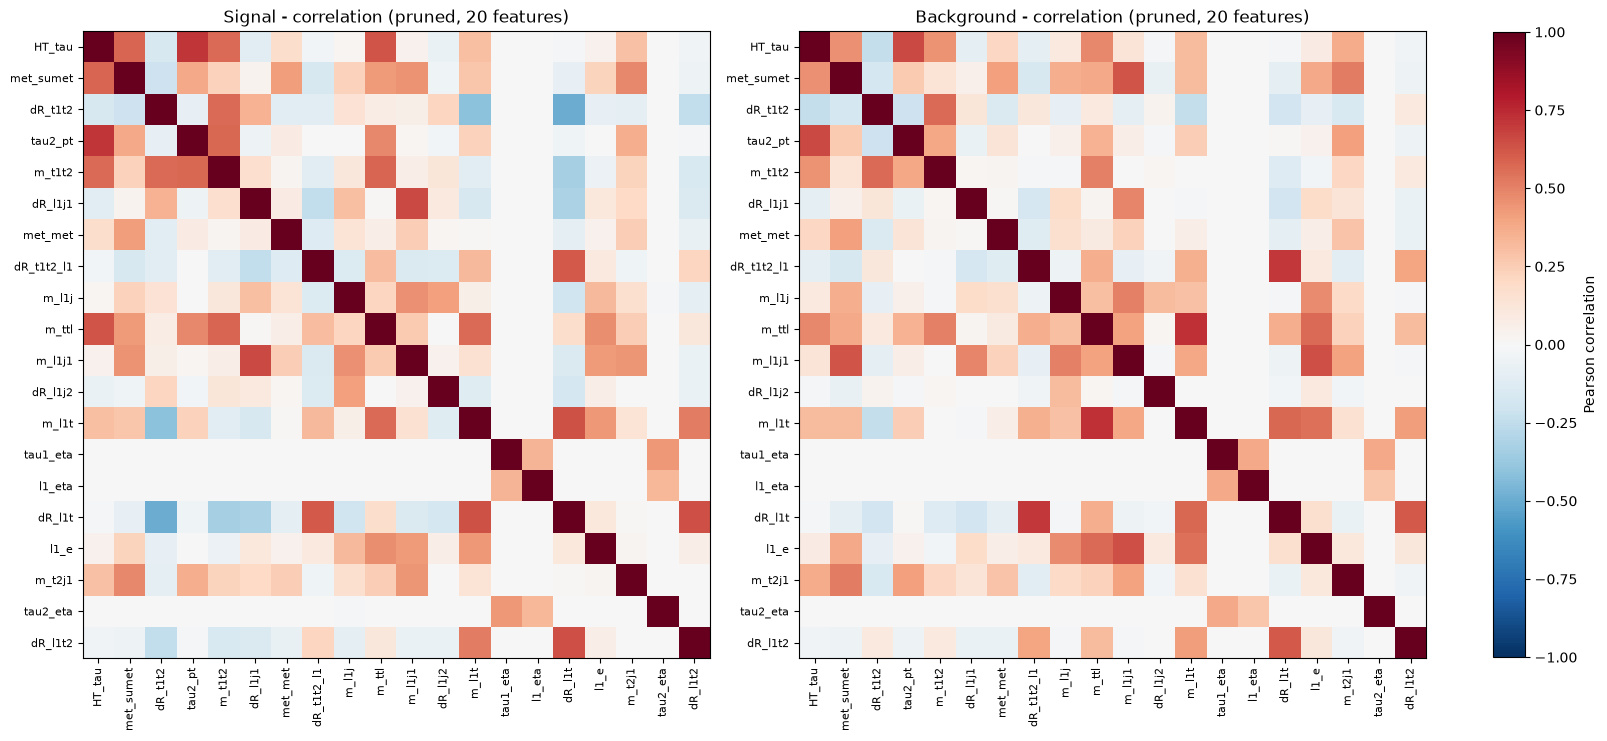

Pairs with |corr| > 0.50 (signal):
HT_tau      tau2_pt      0.716004
dR_l1j1     m_l1j1       0.660874
dR_l1t      dR_l1t2      0.643508
m_l1t       dR_l1t       0.634959
HT_tau      m_ttl        0.626184
dR_t1t2_l1  dR_l1t       0.615619
m_t1t2      m_ttl        0.581193
HT_tau      met_sumet    0.580861
tau2_pt     m_t1t2       0.570922
HT_tau      m_t1t2       0.567705
dR_t1t2     m_t1t2       0.566554
m_ttl       m_l1t        0.566447
m_l1t       dR_l1t2      0.513734

Pairs with |corr| > 0.50 (background):
m_ttl       m_l1t      0.727305
dR_t1t2_l1  dR_l1t     0.706611
HT_tau      tau2_pt    0.658780
m_l1j1      l1_e       0.643583
met_sumet   m_l1j1     0.628670
dR_l1t      dR_l1t2    0.615604
m_l1t       dR_l1t     0.577624
dR_t1t2     m_t1t2     0.566206
m_ttl       l1_e       0.564444
m_l1t       l1_e       0.553811
met_sumet   m_t2j1     0.512608
m_t1t2      m_ttl      0.501867
m_l1j       m_l1j1     0.501741


In [67]:
# --- Correlation of the pruned feature set, ordered by pruned-model importance (Run 2) --
pruned_top_feats = imp_pruned.index.tolist()

pruned_corr_sig = data.loc[data.label == 1, pruned_top_feats].corr()
pruned_corr_bkg = data.loc[data.label == 0, pruned_top_feats].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
for ax, corr, title in [(axes[0], pruned_corr_sig, "Signal"), (axes[1], pruned_corr_bkg, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(pruned_top_feats)))
    ax.set_xticklabels(pruned_top_feats, rotation=90, fontsize=8)
    ax.set_yticks(range(len(pruned_top_feats)))
    ax.set_yticklabels(pruned_top_feats, fontsize=8)
    ax.set_title(f"{title} - correlation (pruned, {len(pruned_top_feats)} features)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")
plt.show()

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(pruned_corr_sig).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(pruned_corr_bkg).to_string())

## Optuna

In [52]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Tune only on the Run-2 training partition. X_val remains outside Optuna and
# is evaluated once after choosing the best hyperparameters.
OPTUNA_FEATURES = PRUNED_FEATURES.copy()  # decorrelated top-20, not the raw top-30
N_TRIALS = 5
N_FOLDS = 3

X_opt = X_train[OPTUNA_FEATURES].reset_index(drop=True)
y_opt = y_train.reset_index(drop=True).to_numpy()
w_opt = np.abs(w_train.reset_index(drop=True).to_numpy())


def make_fit_weights(labels, abs_weights):

    """Balance signal/background for the loss and normalize mean weight to 1."""

    fit_weights = abs_weights.copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def objective(trial):
    params = {
        "n_estimators": 800,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
        "tree_method": "hist",
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "n_jobs": -1,
        "random_state": 42,
    }

    fold_aucs = []
    best_iterations = []
    
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    for fold, (idx_train, idx_valid) in enumerate(cv.split(X_opt, y_opt)):
        fold_model = xgb.XGBClassifier(**params)
        fold_weights = make_fit_weights(y_opt[idx_train], w_opt[idx_train])

        # Class rescaling is unnecessary for ROC AUC: a constant factor applied
        # to one class cancels in the weighted AUC definition.
        
        fold_model.fit(
            X_opt.iloc[idx_train], y_opt[idx_train],
            sample_weight=fold_weights,
            eval_set=[(X_opt.iloc[idx_valid], y_opt[idx_valid])],
            sample_weight_eval_set=[w_opt[idx_valid]],
            verbose=False,
        )

        predictions = fold_model.predict_proba(X_opt.iloc[idx_valid])[:, 1]
        fold_auc = roc_auc_score(
            y_opt[idx_valid], predictions, sample_weight=w_opt[idx_valid]
        )
        fold_aucs.append(fold_auc)
        best_iterations.append(fold_model.best_iteration + 1)

        trial.report(float(np.mean(fold_aucs)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("mean_best_iteration", int(round(np.mean(best_iterations))))
    trial.set_user_attr("fold_aucs", [float(value) for value in fold_aucs])
    return float(np.mean(fold_aucs))


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    study_name="xgb_1l2tau_run2_top15",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True, gc_after_trial=True)

print(f"\nCompleted trials: {len(study.trials)}")
print(f"Best mean CV AUC: {study.best_value:.5f}")
print(f"Mean best iteration: {study.best_trial.user_attrs['mean_best_iteration']}")
print("Fold AUCs:", study.best_trial.user_attrs["fold_aucs"])
print("Best parameters:")
for name, value in study.best_params.items():
    print(f"  {name}: {value}")


/tmp/ipykernel_72546/1084532507.py:86: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),


  0%|          | 0/5 [00:00<?, ?it/s]

[W 2026-07-15 11:20:56,738] Trial 0 failed with parameters: {'learning_rate': 0.047377279007281566, 'max_depth': 8, 'min_child_weight': 17.524101118128137, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 21.76624112345367} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/est3ban3/IFJ_PAN_PROJECT/MVA-Project/venv/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_72546/1084532507.py", line 59, in objective
    fold_model.fit(
    ~~~~~~~~~~~~~~^
        X_opt.iloc[idx_train], y_opt[idx_train],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        verbose=False,
        ^^^^^^^^^^^^^^
    )
    ^
  File "/home/est3ban3/IFJ_PAN_PROJECT/MVA-Project/venv/lib/python3.14/site-packages/xgboost/core.py", line 553, in inner_f
    re

KeyboardInterrupt: 

In [29]:
# --- Final model from Optuna -------------------------------------------------
# Use the CV-selected number of trees. Do NOT early-stop on X_val: keeping it
# out of tuning makes its AUC a cleaner final Run-2 holdout estimate.

best_n_estimators = study.best_trial.user_attrs["mean_best_iteration"]
best_params = {
    **study.best_params,
    "n_estimators": best_n_estimators,
    "tree_method": "hist",
    "eval_metric": "auc",
    "n_jobs": -1,
    "random_state": 42,
}

final_w_fit = make_fit_weights(
    y_train.to_numpy(), np.abs(w_train.to_numpy())
)
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(
    X_train[OPTUNA_FEATURES], y_train,
    sample_weight=final_w_fit,
    verbose=False,
)

pred_train = final_model.predict_proba(X_train[OPTUNA_FEATURES])[:, 1]
pred_holdout = final_model.predict_proba(X_val[OPTUNA_FEATURES])[:, 1]
w_holdout_abs = np.abs(w_val.to_numpy())

auc_train_opt = roc_auc_score(y_train, pred_train, sample_weight=final_w_fit)
auc_holdout_opt = roc_auc_score(y_val, pred_holdout, sample_weight=w_holdout_abs)
auc_holdout_unweighted = roc_auc_score(y_val, pred_holdout)

print(f"Features: {len(OPTUNA_FEATURES)}")
print(f"Trees: {best_n_estimators}")
print(f"Weighted AUC train:       {auc_train_opt:.5f}")
print(f"Weighted AUC Run-2 holdout: {auc_holdout_opt:.5f}")
print(f"Unweighted AUC holdout:   {auc_holdout_unweighted:.5f}")
print(f"Overtraining gap:         {auc_train_opt - auc_holdout_opt:.5f}")


Features: 30
Trees: 678
Weighted AUC train:       0.96541
Weighted AUC Run-2 holdout: 0.93934
Unweighted AUC holdout:   0.79925
Overtraining gap:         0.02607


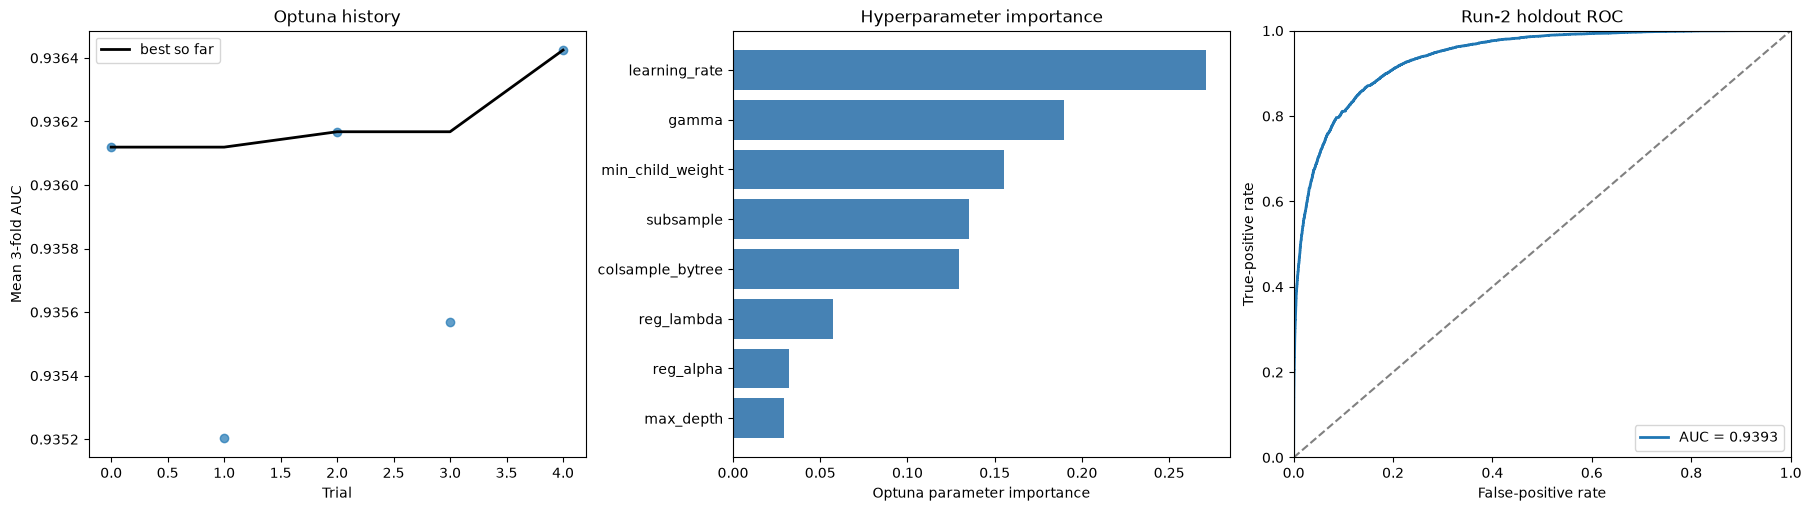

Final Optuna features:
['HT_tau', 'dR_t1t2', 'm_t1t2', 'SumPt_t1t2', 'met_sumet', 'dR_l1j1', 'HT', 'tau1_pt', 'm_l1j', 'tau2_pt', 'met_met', 'm_ttl', 'm_l1j1', 'm_l1t', 'dR_t1t2_l1', 'HT_lepMET', 'm_l1t1', 'tau1_eta', 'dR_l1j2', 'dR_l1t', 'tau2_eta', 'j1_pt', 'l1_eta', 'm_all', 'dR_l1t1', 'dR_l1t2', 'l1_e', 'HT_lep', 'HT_all', 'm_t2j1']


In [30]:
from sklearn.metrics import roc_curve

# --- Optuna diagnostics and holdout ROC ------------------------------------
trials = study.trials_dataframe()
complete = trials.loc[trials["state"] == "COMPLETE"].copy()
param_importance = optuna.importance.get_param_importances(study)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
axes[0].plot(
    complete["number"], complete["value"].cummax(),
    color="black", linewidth=2, label="best so far"
)
axes[0].set(xlabel="Trial", ylabel="Mean 3-fold AUC", title="Optuna history")
axes[0].legend()

names = list(param_importance)
values = [param_importance[name] for name in names]
axes[1].barh(names[::-1], values[::-1], color="steelblue")
axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

fpr, tpr, _ = roc_curve(
    y_val, pred_holdout, sample_weight=w_holdout_abs
)
axes[2].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_holdout_opt:.4f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray")
axes[2].set(
    xlabel="False-positive rate", ylabel="True-positive rate",
    title="Run-2 holdout ROC", xlim=(0, 1), ylim=(0, 1)
)
axes[2].legend(loc="lower right")
plt.show()

print("Final Optuna features:")
print(OPTUNA_FEATURES)


## Optuna-tuned model — feature importance & correlation

Optuna-tuned model — feature importance by total gain:
              total_gain  gain_frac  weight
HT_tau      3.225718e+06   0.319464  2025.0
SumPt_t1t2  9.234194e+05   0.091452  2630.0
tau1_pt     8.552607e+05   0.084702  1653.0
dR_t1t2     5.897788e+05   0.058410  3629.0
HT          4.443386e+05   0.044006  1863.0
met_sumet   4.006042e+05   0.039674  3028.0
m_t1t2      3.955848e+05   0.039177  3388.0
tau2_pt     3.737283e+05   0.037013  2431.0
dR_l1j1     3.105165e+05   0.030752  2460.0
m_l1j       2.344441e+05   0.023219  2422.0
met_met     1.949252e+05   0.019305  2781.0
m_l1j1      1.715662e+05   0.016991  1957.0
m_ttl       1.667011e+05   0.016510  2285.0
HT_all      1.369546e+05   0.013564  1530.0
dR_l1j2     1.351517e+05   0.013385  2560.0
m_l1t1      1.321792e+05   0.013091  2194.0
dR_t1t2_l1  1.319782e+05   0.013071  2286.0
j1_pt       1.238068e+05   0.012261  2639.0
m_l1t       1.191407e+05   0.011799  2186.0
HT_lepMET   1.163048e+05   0.011518  2294.0
tau1_eta    1.141569e

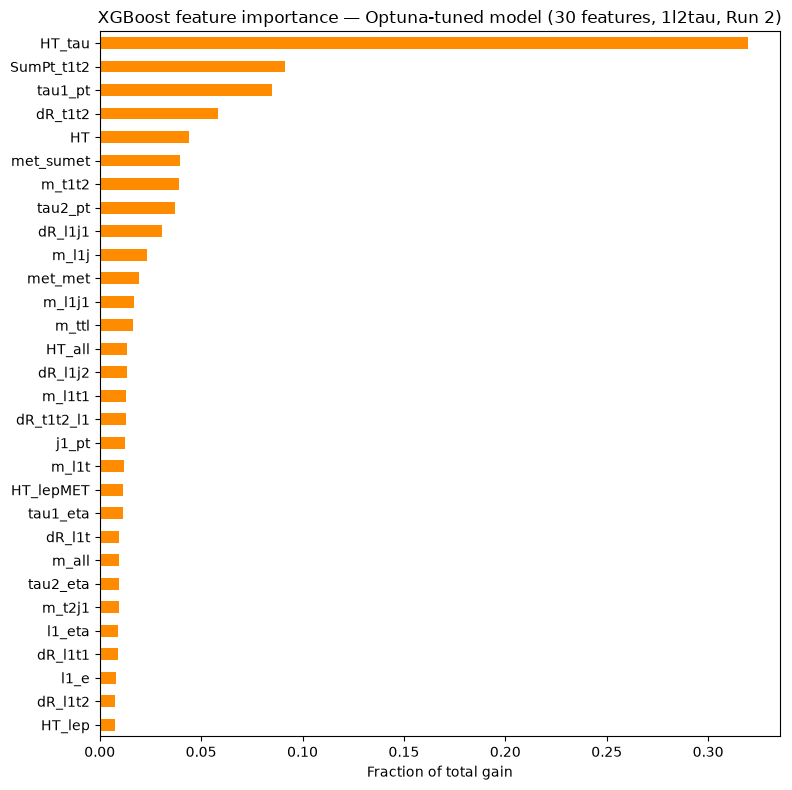

In [31]:
# --- Feature importance of the Optuna-tuned final model ---------------------
# Same metric (total_gain) as the baseline model, but restricted to
# OPTUNA_FEATURES and reflecting the tuned hyperparameters (depth, gamma,
# regularization, etc.), so the ranking can shift relative to the baseline.

final_booster = final_model.get_booster()

final_imp = pd.DataFrame({
    t: final_booster.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(OPTUNA_FEATURES).fillna(0.0)

final_imp = final_imp.sort_values("total_gain", ascending=False)
final_imp["gain_frac"] = final_imp["total_gain"] / final_imp["total_gain"].sum()

print("Optuna-tuned model — feature importance by total gain:")
print(final_imp[["total_gain", "gain_frac", "weight"]].to_string())
print(f"\nFeatures never used in a split: {(final_imp['total_gain'] == 0).sum()} / {len(OPTUNA_FEATURES)}")

fig, ax = plt.subplots(figsize=(8, 8))
final_imp["gain_frac"][::-1].plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance — Optuna-tuned model ({len(OPTUNA_FEATURES)} features, 1l2tau, Run 2)")
plt.tight_layout()
plt.show()


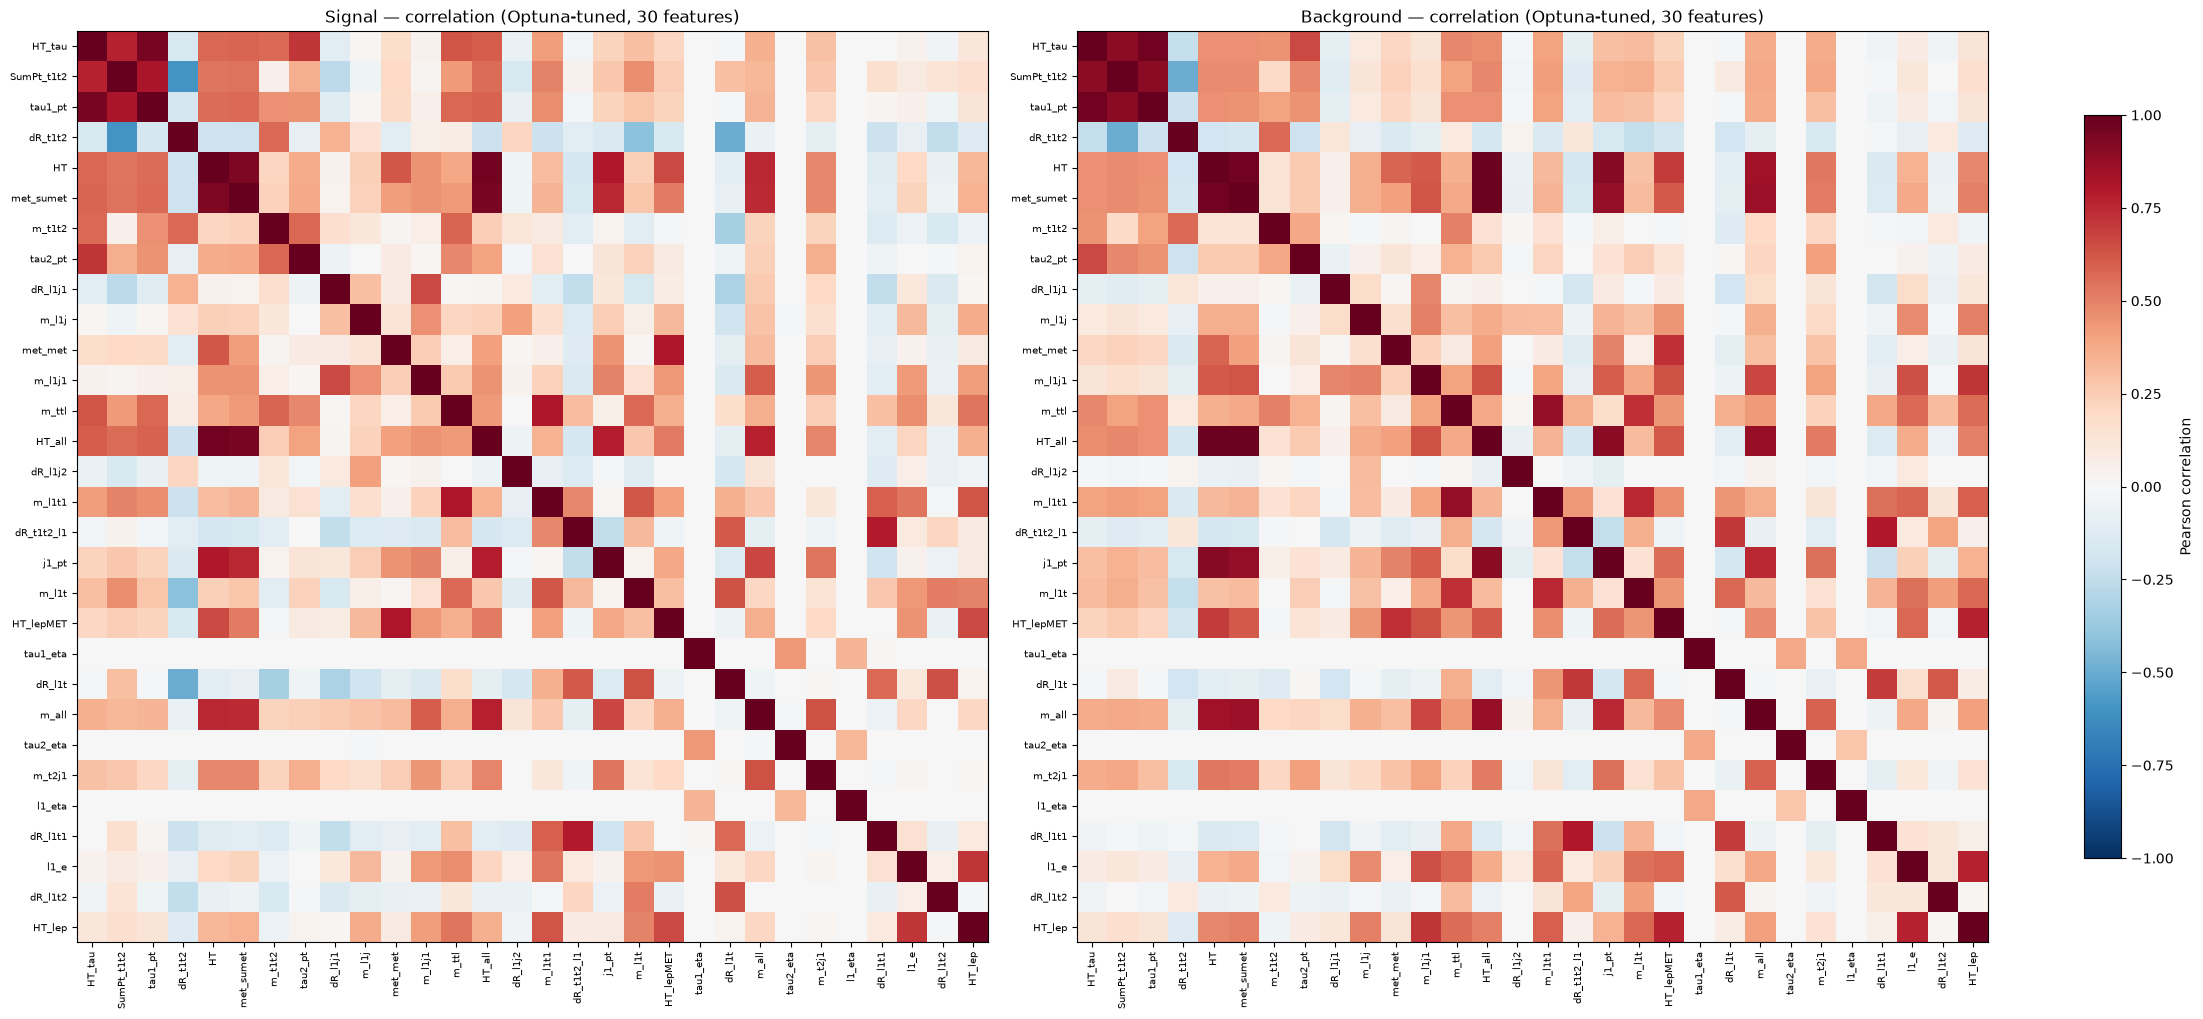

Pairs with |corr| > 0.9 (signal):
HT         HT_all       0.968501
met_sumet  HT_all       0.951155
HT_tau     tau1_pt      0.945766
HT         met_sumet    0.930010

Pairs with |corr| > 0.9 (background):
met_sumet   HT_all       0.983736
HT          HT_all       0.980366
HT_tau      tau1_pt      0.967306
HT          met_sumet    0.965350
            j1_pt        0.909921
SumPt_t1t2  tau1_pt      0.903307
HT_all      j1_pt        0.900532


In [32]:
# --- Correlation of features, ordered by Optuna-tuned model importance ------
final_top_feats = final_imp.index.tolist()

final_corr_sig = data.loc[data.label == 1, final_top_feats].corr()
final_corr_bkg = data.loc[data.label == 0, final_top_feats].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
for ax, corr, title in [(axes[0], final_corr_sig, "Signal"), (axes[1], final_corr_bkg, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(final_top_feats)))
    ax.set_xticklabels(final_top_feats, rotation=90, fontsize=7)
    ax.set_yticks(range(len(final_top_feats)))
    ax.set_yticklabels(final_top_feats, fontsize=7)
    ax.set_title(f"{title} — correlation (Optuna-tuned, {len(final_top_feats)} features)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")
plt.show()

# Reuses top_pairs() defined earlier in the notebook (correlation cell).
print("Pairs with |corr| > 0.9 (signal):")
print(top_pairs(final_corr_sig).to_string())
print("\nPairs with |corr| > 0.9 (background):")
print(top_pairs(final_corr_bkg).to_string())


## Run 3

In [33]:
# ---- Run 3 configuration ---------------------------------------------------
BASE_DIR_R3 = Path("PPSSP_2026/1l2tau/run3")   # 1 lepton + 2 taus, Run 3
RUN_R3 = 3

# Feature list rebuilt from branches common to all Run 3 files (kept separate
# from Run 2's `features` in case branches differ between campaigns).
common_r3 = None
for proc, (fname, _) in files.items():
    keys = set(uproot.open({str(BASE_DIR_R3 / fname): TREE_NAME}).keys())
    common_r3 = keys if common_r3 is None else common_r3 & keys
features_r3 = sorted(b for b in common_r3 if is_feature(b))

print(f"{len(features_r3)} candidate features (common to all {len(files)} Run 3 files, leakage-free)\n")

# ---- Extraction loop ---------------------------------------------------------
dfs_r3 = []
for proc, (fname, label) in files.items():
    tree = uproot.open({str(BASE_DIR_R3 / fname): TREE_NAME})
    df_r3 = tree.arrays(features_r3 + WEIGHT_PARTS, cut=PRESELECTION, library="pd")

    df_r3["w_phys"]  = df_r3["weight"] * df_r3["weights"]
    df_r3["label"]   = label
    df_r3["process"] = proc
    df_r3["run"]     = RUN_R3
    dfs_r3.append(df_r3)
    print(f"{proc:12s}: {len(df_r3):>8d} events after preselection")

data_r3 = pd.concat(dfs_r3, ignore_index=True)

# ---- Post-concat cleaning -----------------------------------------------------
# 1) Constant / empty features (zero variance) -> drop
nun_r3 = data_r3[features_r3].nunique()
const_r3 = nun_r3[nun_r3 <= 1].index.tolist()
features_r3 = [f for f in features_r3 if f not in const_r3]
data_r3 = data_r3.drop(columns=const_r3)
print(f"\nDropped {len(const_r3)} constant/empty features:\n  {sorted(const_r3)}")

# 2) Sentinel values (e.g. -999) -> NaN
for f in features_r3:
    m = data_r3[f] < -100
    if m.any():
        print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
        data_r3[f] = data_r3[f].mask(m)

print(f"\n{len(features_r3)} final features")
print(f"Total: {len(data_r3)} events | signal = {(data_r3.label==1).sum()} | background = {(data_r3.label==0).sum()}")
print(f"Yield (w_phys): signal = {data_r3.loc[data_r3.label==1,'w_phys'].sum():.2f} | background = {data_r3.loc[data_r3.label==0,'w_phys'].sum():.2f}")
data_r3.head()

87 candidate features (common to all 10 Run 3 files, leakage-free)

signal_ggF  :   191580 events after preselection
signal_VBF  :    13470 events after preselection
Diboson     :   628676 events after preselection
Zjets       :   157073 events after preselection
Wjets       :    39061 events after preselection
ttbar       :    40832 events after preselection
tops        :   161226 events after preselection
SingleH     :    38425 events after preselection
Vgamma      :    14295 events after preselection
VVV         :    40254 events after preselection

Dropped 19 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode', 'tau2_passOR']

68 final features
Total: 1324892 events | signal = 205050 | background = 1119842
Yield (w_phys): signal

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_eta,tau2_nprong,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,295410.93750,225582.06250,139812.218750,27723.984375,97552.882812,58045.851562,74214.664062,66489.398438,56902.617188,3.118024,...,1.007036,1,-1.304773,23250.283203,0.000896,0.039867,0.000036,1,signal_ggF,3
1,505036.75000,313843.37500,113722.625000,144957.328125,336150.687500,55163.425781,181061.453125,219900.609375,52511.066406,0.697824,...,-2.060293,1,-1.315973,24946.242188,0.000896,0.041900,0.000038,1,signal_ggF,3
2,317003.15625,279036.90625,194843.140625,20118.156250,58084.398438,64075.617188,46115.941406,85579.804688,29741.353516,2.050562,...,-1.885038,1,-0.555000,26483.121094,0.000896,0.049289,0.000044,1,signal_ggF,3
3,505021.50000,447686.37500,232611.265625,33814.699219,91149.812500,181260.421875,131265.046875,131265.046875,88135.117188,0.449383,...,-0.694575,3,-2.462519,50765.574219,0.000896,0.032946,0.000030,1,signal_ggF,3
4,663091.81250,590826.00000,457783.593750,91843.343750,164109.218750,41199.023438,113508.242188,182620.421875,21455.128906,3.566932,...,2.458508,1,2.298223,20445.324219,0.000896,0.023983,0.000021,1,signal_ggF,3


In [40]:
print(data_r3.shape)

(1324892, 74)


In [35]:
# 80 / 20 train-validation split for Run 3, keeping the signal/background balance
train_df_r3, val_df_r3 = train_test_split(
    data_r3,
    test_size=0.20,
    random_state=42,
    stratify=data_r3["label"],
)

X_train_r3 = train_df_r3[features_r3]
y_train_r3 = train_df_r3["label"]
w_train_r3 = train_df_r3["w_phys"]

X_val_r3 = val_df_r3[features_r3]
y_val_r3 = val_df_r3["label"]
w_val_r3 = val_df_r3["w_phys"]

print(f"Train: {len(train_df_r3)} events | signal = {(y_train_r3==1).sum()} | background = {(y_train_r3==0).sum()}")
print(f"Val:   {len(val_df_r3)} events | signal = {(y_val_r3==1).sum()} | background = {(y_val_r3==0).sum()}")

Train: 1059913 events | signal = 164040 | background = 895873
Val:   264979 events | signal = 41010 | background = 223969


In [43]:
# ---- Persist the train/val split to ROOT files (Run 3) ---------------------
SPLIT_DIR_R3 = BASE_DIR_R3 / "splits"
SPLIT_DIR_R3.mkdir(parents=True, exist_ok=True)

TRAIN_ROOT_R3 = SPLIT_DIR_R3 / "train.root"
VAL_ROOT_R3   = SPLIT_DIR_R3 / "val.root"

with uproot.recreate(TRAIN_ROOT_R3) as f:
    f["tree"] = train_df_r3.reset_index(drop=True)

with uproot.recreate(VAL_ROOT_R3) as f:
    f["tree"] = val_df_r3.reset_index(drop=True)

print(f"Wrote {len(train_df_r3)} training events   -> {TRAIN_ROOT_R3}")
print(f"Wrote {len(val_df_r3)} validation events -> {VAL_ROOT_R3}")

# --- Round-trip check + reload pattern for later use -------------------------
train_df_r3_check = uproot.open({str(TRAIN_ROOT_R3): "tree"}).arrays(library="pd")
val_df_r3_check   = uproot.open({str(VAL_ROOT_R3): "tree"}).arrays(library="pd")
assert len(train_df_r3_check) == len(train_df_r3) and len(val_df_r3_check) == len(val_df_r3)
print("Round-trip OK - reload later with:")
print('  train_df_r3 = uproot.open({str(TRAIN_ROOT_R3): "tree"}).arrays(library="pd")')
print('  val_df_r3   = uproot.open({str(VAL_ROOT_R3): "tree"}).arrays(library="pd")')

Wrote 1059913 training events   -> PPSSP_2026/1l2tau/run3/splits/train.root
Wrote 264979 validation events -> PPSSP_2026/1l2tau/run3/splits/val.root
Round-trip OK - reload later with:
  train_df_r3 = uproot.open({str(TRAIN_ROOT_R3): "tree"}).arrays(library="pd")
  val_df_r3   = uproot.open({str(VAL_ROOT_R3): "tree"}).arrays(library="pd")


## XGBoost (Run 3)

In [36]:
w_fit_r3 = np.abs(w_train_r3.to_numpy())

sum_sig_r3, sum_bkg_r3 = w_fit_r3[y_train_r3 == 1].sum(), w_fit_r3[y_train_r3 == 0].sum()
w_fit_r3[y_train_r3 == 1] *= sum_bkg_r3 / sum_sig_r3
w_fit_r3 *= len(w_fit_r3) / w_fit_r3.sum()

w_val_fit_r3 = np.abs(w_val_r3.to_numpy())   # for the weighted validation AUC

print(f"signal weight scale factor: {sum_bkg_r3/sum_sig_r3:.1f}")

model_r3 = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)

model_r3.fit(
    X_train_r3, y_train_r3,
    sample_weight=w_fit_r3,
    eval_set=[(X_val_r3, y_val_r3)],
    sample_weight_eval_set=[w_val_fit_r3],
    verbose=50,
)

print(f"\nBest iteration: {model_r3.best_iteration}")
auc_train_r3 = roc_auc_score(y_train_r3, model_r3.predict_proba(X_train_r3)[:, 1], sample_weight=np.abs(w_train_r3))
auc_val_r3   = roc_auc_score(y_val_r3,   model_r3.predict_proba(X_val_r3)[:, 1],   sample_weight=w_val_fit_r3)
print(f"Weighted AUC: train = {auc_train_r3:.4f} | validation = {auc_val_r3:.4f}")

signal weight scale factor: 12555.7
[0]	validation_0-auc:0.91640
[50]	validation_0-auc:0.94140
[100]	validation_0-auc:0.94579
[150]	validation_0-auc:0.94787
[200]	validation_0-auc:0.94918
[250]	validation_0-auc:0.94976
[300]	validation_0-auc:0.95037
[350]	validation_0-auc:0.95054
[394]	validation_0-auc:0.95049

Best iteration: 364
Weighted AUC: train = 0.9764 | validation = 0.9505


Top 30 features by total gain (Run 3):
               total_gain  gain_frac  weight
HT_tau       2.134588e+06   0.458640   491.0
dR_t1t2      2.196237e+05   0.047189   654.0
SumPt_t1t2   1.570941e+05   0.033753   604.0
HT           1.393965e+05   0.029951   332.0
m_t1t2       1.275712e+05   0.027410   664.0
tau1_pt      1.261591e+05   0.027107   413.0
dR_l1j1      1.112302e+05   0.023899   455.0
tau2_pt      9.902445e+04   0.021277   519.0
met_sumet    9.631555e+04   0.020694   551.0
m_l1j        9.236952e+04   0.019847   480.0
met_met      6.578614e+04   0.014135   560.0
m_ttl        5.623646e+04   0.012083   419.0
dR_t1t2_l1   5.011781e+04   0.010768   453.0
m_l1t        4.840195e+04   0.010400   460.0
dR_l1t       4.474311e+04   0.009614   427.0
dR_l1j2      4.366011e+04   0.009381   422.0
HT_lepMET    4.097146e+04   0.008803   393.0
m_l1j1       3.924028e+04   0.008431   405.0
tau2_eta     3.569286e+04   0.007669   457.0
l1_eta       3.479009e+04   0.007475   361.0
m_l1t1       3.4

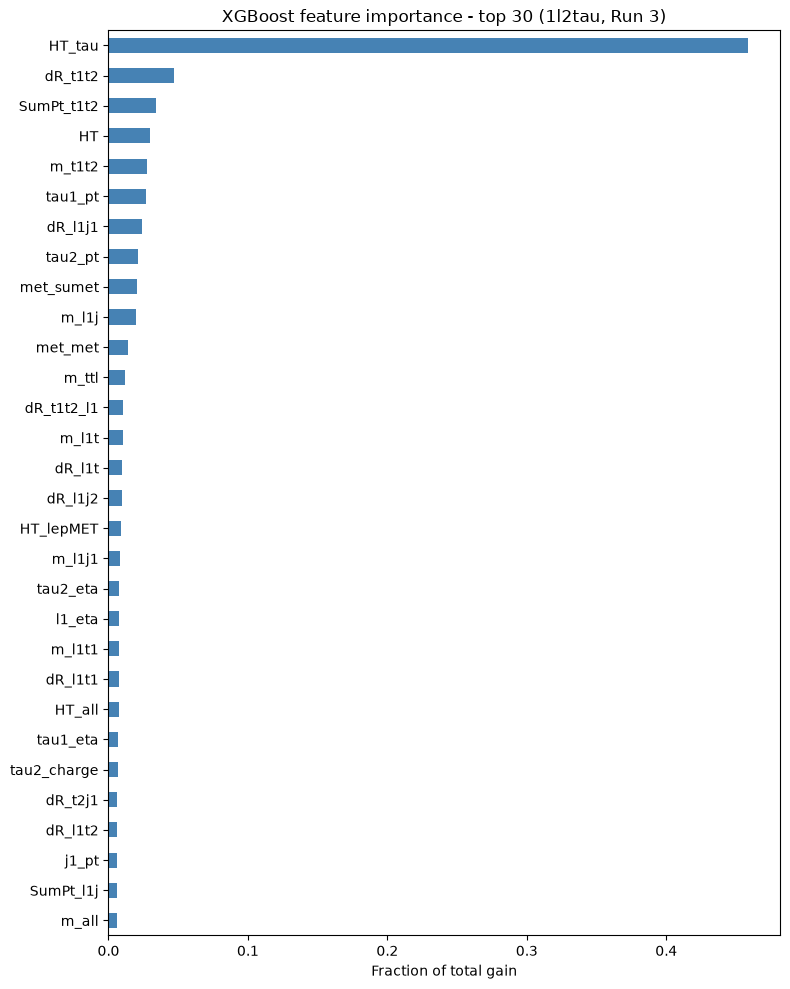

In [37]:
# --- Feature importance (Run 3) ---------------------------------------------
booster_r3 = model_r3.get_booster()

imp_r3 = pd.DataFrame({
    t: booster_r3.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(features_r3).fillna(0.0)

imp_r3 = imp_r3.sort_values("total_gain", ascending=False)
imp_r3["gain_frac"] = imp_r3["total_gain"] / imp_r3["total_gain"].sum()

print("Top 30 features by total gain (Run 3):")
print(imp_r3[["total_gain", "gain_frac", "weight"]].head(30).to_string())
print(f"\nFeatures never used in a split: {(imp_r3['total_gain'] == 0).sum()} / {len(features_r3)}")

fig, ax = plt.subplots(figsize=(8, 10))
imp_r3["gain_frac"].head(TOP_N)[::-1].plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance - top {TOP_N} (1l2tau, Run 3)")
plt.tight_layout()
plt.show()

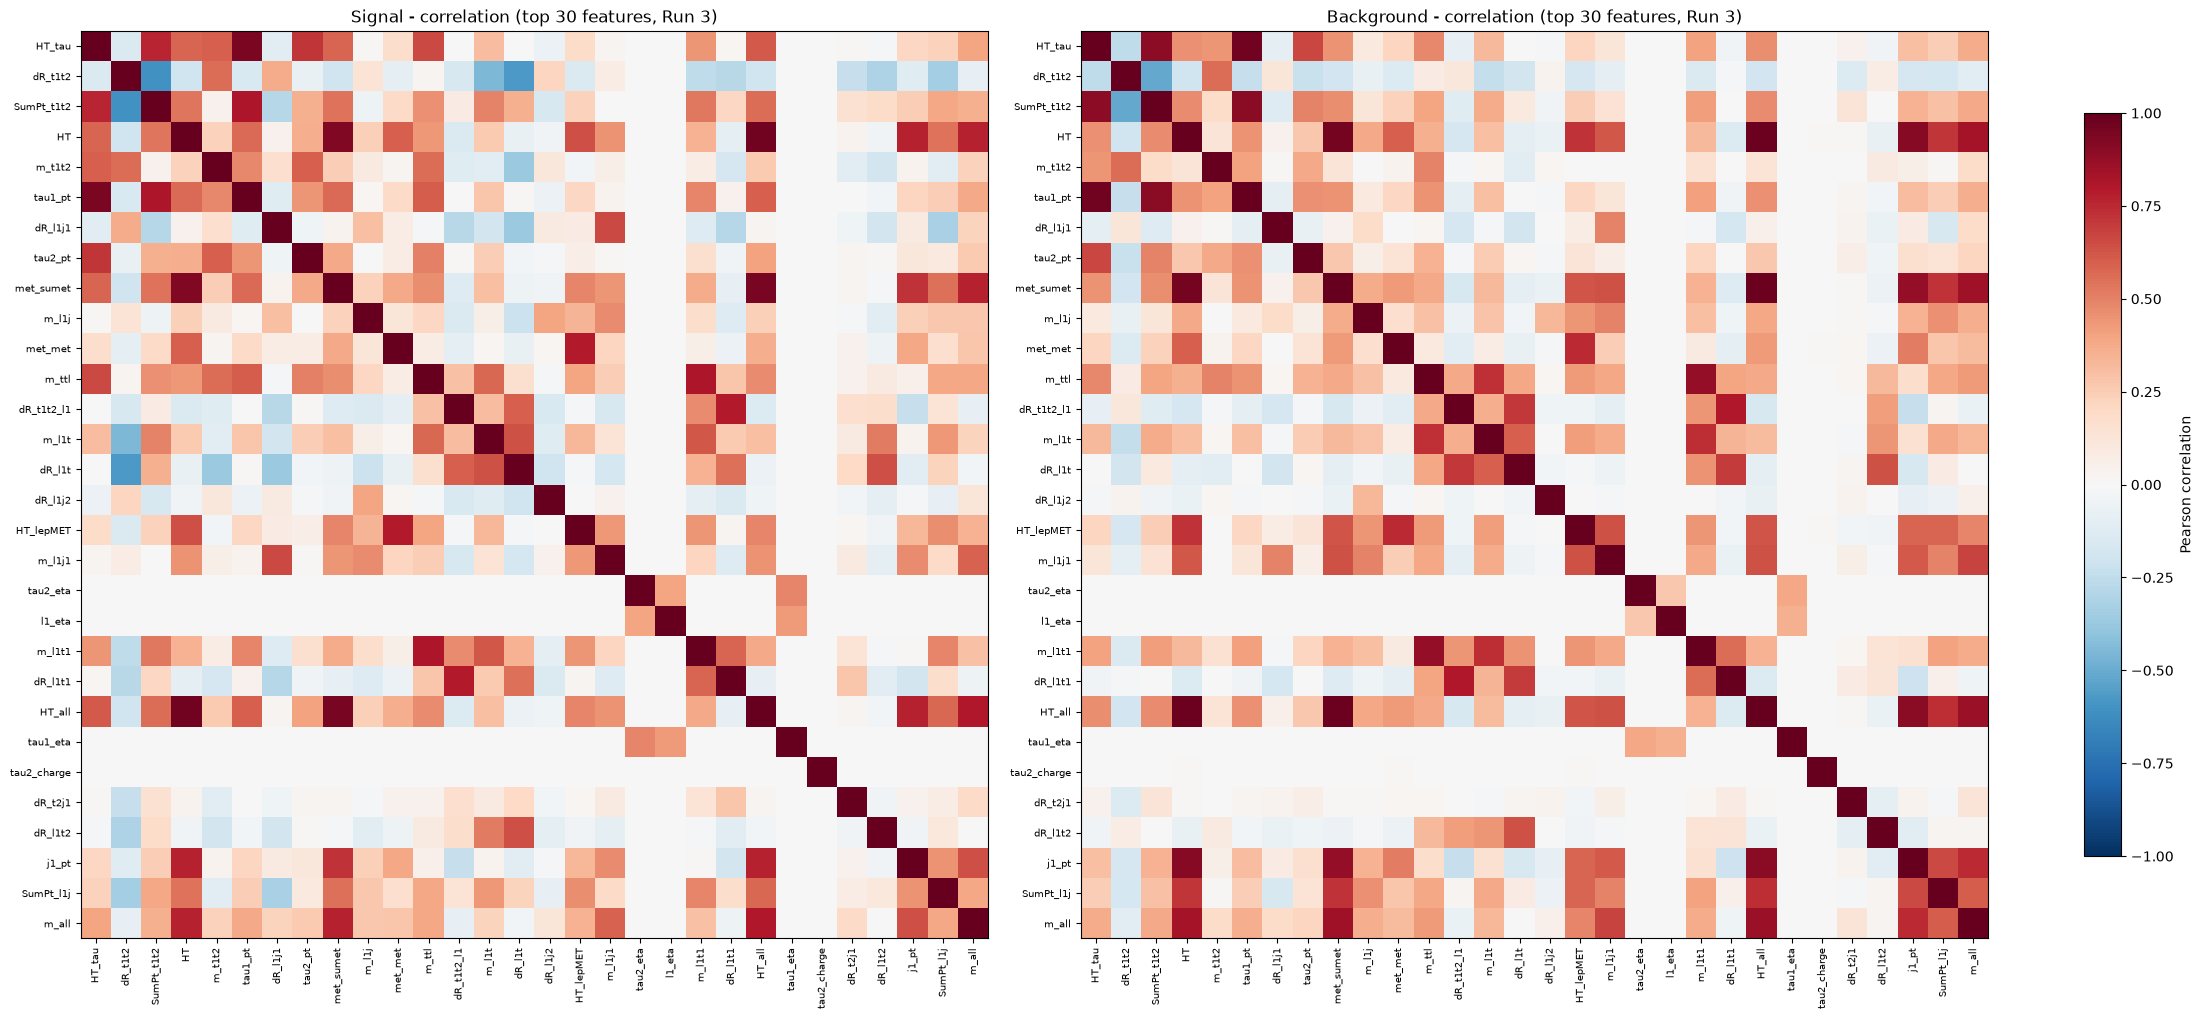

Pairs with |corr| > 0.9 (signal):
HT         HT_all       0.965227
met_sumet  HT_all       0.948426
HT_tau     tau1_pt      0.944209
HT         met_sumet    0.924214

Pairs with |corr| > 0.9 (background):
met_sumet   HT_all       0.979360
HT          HT_all       0.978909
HT_tau      tau1_pt      0.967156
HT          met_sumet    0.960698
            j1_pt        0.911466
SumPt_t1t2  tau1_pt      0.903089
HT_all      j1_pt        0.901840


In [38]:
# --- Correlation of the top features (Run 3) --------------------------------
top_feats_r3 = imp_r3.index[:TOP_N].tolist()

corr_sig_r3 = data_r3.loc[data_r3.label == 1, top_feats_r3].corr()
corr_bkg_r3 = data_r3.loc[data_r3.label == 0, top_feats_r3].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
for ax, corr, title in [(axes[0], corr_sig_r3, "Signal"), (axes[1], corr_bkg_r3, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(top_feats_r3)))
    ax.set_xticklabels(top_feats_r3, rotation=90, fontsize=7)
    ax.set_yticks(range(len(top_feats_r3)))
    ax.set_yticklabels(top_feats_r3, fontsize=7)
    ax.set_title(f"{title} - correlation (top {TOP_N} features, Run 3)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")
plt.show()

print("Pairs with |corr| > 0.9 (signal):")
print(top_pairs(corr_sig_r3).to_string())
print("\nPairs with |corr| > 0.9 (background):")
print(top_pairs(corr_bkg_r3).to_string())

In [53]:
# --- Prune redundant (highly correlated) features down to N_KEEP (Run 3) ---
# Same logic as the Run 2 pruning cell: walk top_feats_r3 in importance order,
# drop any feature that is > CORR_THRESH correlated (signal OR background)
# with a more-important feature already kept.

CORR_THRESH = 0.75
N_KEEP = 20

corr_max_r3 = corr_sig_r3.abs().combine(corr_bkg_r3.abs(), np.maximum)

kept_r3, dropped_r3 = [], []
for feat in top_feats_r3:
    redundant_with = next(
        (k for k in kept_r3 if corr_max_r3.loc[feat, k] > CORR_THRESH), None
    )
    if redundant_with is None:
        kept_r3.append(feat)
    else:
        dropped_r3.append((feat, redundant_with, corr_max_r3.loc[feat, redundant_with]))
    if len(kept_r3) == N_KEEP:
        break

if len(kept_r3) < N_KEEP:
    print(f"WARNING: only {len(kept_r3)}/{N_KEEP} survivors found within top_feats_r3 "
          f"({len(top_feats_r3)} features) - raise TOP_N or lower CORR_THRESH.")

print(f"Kept {len(kept_r3)} decorrelated features (most -> least important):")
for i, feat in enumerate(kept_r3, 1):
    print(f"  {i:2d}. {feat}")

print(f"\nDropped {len(dropped_r3)} redundant features (|corr| > {CORR_THRESH} with a more important feature):")
for feat, because_of, corr_val in dropped_r3:
    print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

PRUNED_FEATURES_R3 = kept_r3

Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. dR_t1t2
   3. HT
   4. m_t1t2
   5. dR_l1j1
   6. tau2_pt
   7. m_l1j
   8. met_met
   9. m_ttl
  10. dR_t1t2_l1
  11. m_l1t
  12. dR_l1t
  13. dR_l1j2
  14. m_l1j1
  15. tau2_eta
  16. l1_eta
  17. tau1_eta
  18. tau2_charge
  19. dR_t2j1
  20. dR_l1t2

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.898)
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  met_sumet       -> redundant with HT              (|corr| = 0.961)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.793)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.880)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  HT_all          -> redundant with HT              (|corr| = 0.979)


## Run after cut

In [56]:
# --- Retrain baseline XGBoost using only the pruned top-20 features (Run 3) --
model_r3_pruned = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)

model_r3_pruned.fit(
    X_train_r3[PRUNED_FEATURES_R3], y_train_r3,
    sample_weight=w_fit_r3,
    eval_set=[(X_val_r3[PRUNED_FEATURES_R3], y_val_r3)],
    sample_weight_eval_set=[w_val_fit_r3],
    verbose=50,
)

print(f"\nBest iteration: {model_r3_pruned.best_iteration}")
auc_train_r3_pruned = roc_auc_score(y_train_r3, model_r3_pruned.predict_proba(X_train_r3[PRUNED_FEATURES_R3])[:, 1], sample_weight=np.abs(w_train_r3))
auc_val_r3_pruned   = roc_auc_score(y_val_r3,   model_r3_pruned.predict_proba(X_val_r3[PRUNED_FEATURES_R3])[:, 1],   sample_weight=w_val_fit_r3)
print(f"Weighted AUC (pruned {len(PRUNED_FEATURES_R3)} features): train = {auc_train_r3_pruned:.4f} | validation = {auc_val_r3_pruned:.4f}")
print(f"Comparison - full {len(features_r3)}-feature baseline:    train = {auc_train_r3:.4f} | validation = {auc_val_r3:.4f}")

[0]	validation_0-auc:0.91045
[50]	validation_0-auc:0.93656
[100]	validation_0-auc:0.93911
[150]	validation_0-auc:0.94015
[200]	validation_0-auc:0.94059
[250]	validation_0-auc:0.94090
[300]	validation_0-auc:0.94099
[343]	validation_0-auc:0.94107

Best iteration: 313
Weighted AUC (pruned 20 features): train = 0.9650 | validation = 0.9411
Comparison - full 68-feature baseline:    train = 0.9764 | validation = 0.9505


Pruned model (20 features) - importance by total gain (Run 3):
               total_gain  gain_frac  weight
HT_tau       1.796970e+06   0.421383  1230.0
HT           4.185633e+05   0.098151  1259.0
dR_t1t2      3.504845e+05   0.082187  1373.0
tau2_pt      3.304988e+05   0.077501  1059.0
m_t1t2       1.713577e+05   0.040183  1174.0
dR_l1j1      1.370736e+05   0.032143  1012.0
met_met      1.093292e+05   0.025637  1150.0
dR_t1t2_l1   1.056577e+05   0.024776  1032.0
m_l1j        1.033792e+05   0.024242   968.0
m_l1t        9.513732e+04   0.022309  1083.0
m_ttl        9.186225e+04   0.021541  1026.0
dR_l1j2      9.079388e+04   0.021291  1099.0
m_l1j1       8.855536e+04   0.020766   881.0
dR_t2j1      7.067587e+04   0.016573  1107.0
l1_eta       7.010909e+04   0.016440   960.0
tau1_eta     6.298032e+04   0.014769  1051.0
tau2_eta     6.131839e+04   0.014379  1005.0
dR_l1t       5.462950e+04   0.012810   924.0
dR_l1t2      5.148274e+04   0.012073   866.0
tau2_charge  3.603385e+03   0.000845 

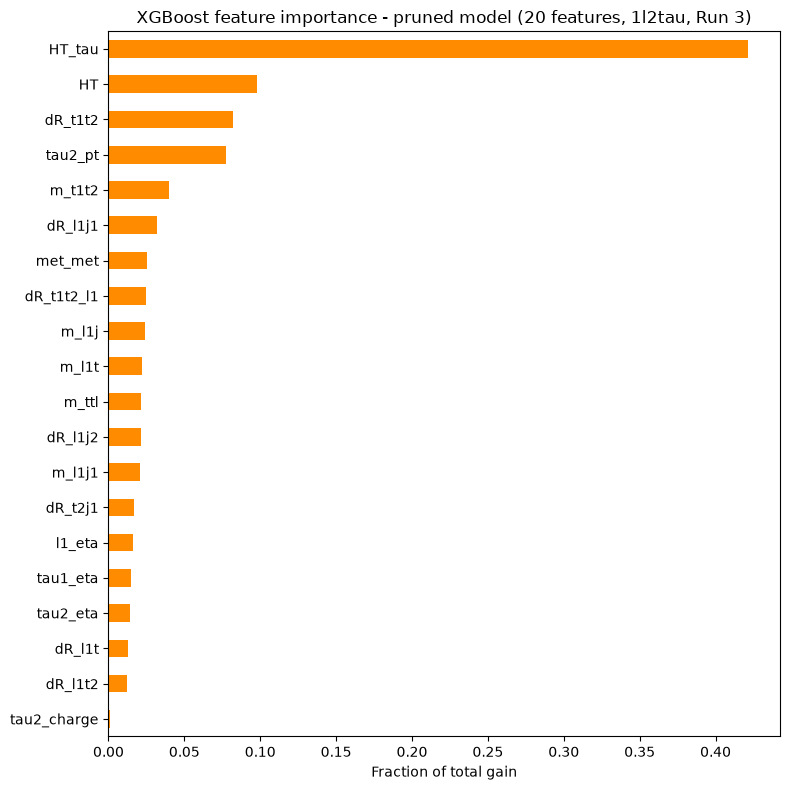

In [62]:
# --- Feature importance of the pruned model (Run 3) --------------------------
booster_r3_pruned = model_r3_pruned.get_booster()

imp_r3_pruned = pd.DataFrame({
    t: booster_r3_pruned.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(PRUNED_FEATURES_R3).fillna(0.0)

imp_r3_pruned = imp_r3_pruned.sort_values("total_gain", ascending=False)
imp_r3_pruned["gain_frac"] = imp_r3_pruned["total_gain"] / imp_r3_pruned["total_gain"].sum()

print("Pruned model (20 features) - importance by total gain (Run 3):")
print(imp_r3_pruned[["total_gain", "gain_frac", "weight"]].to_string())
print(f"\nFeatures never used in a split: {(imp_r3_pruned['total_gain'] == 0).sum()} / {len(PRUNED_FEATURES_R3)}")

fig, ax = plt.subplots(figsize=(8, 8))
imp_r3_pruned["gain_frac"][::-1].plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance - pruned model ({len(PRUNED_FEATURES_R3)} features, 1l2tau, Run 3)")
plt.tight_layout()
plt.show()

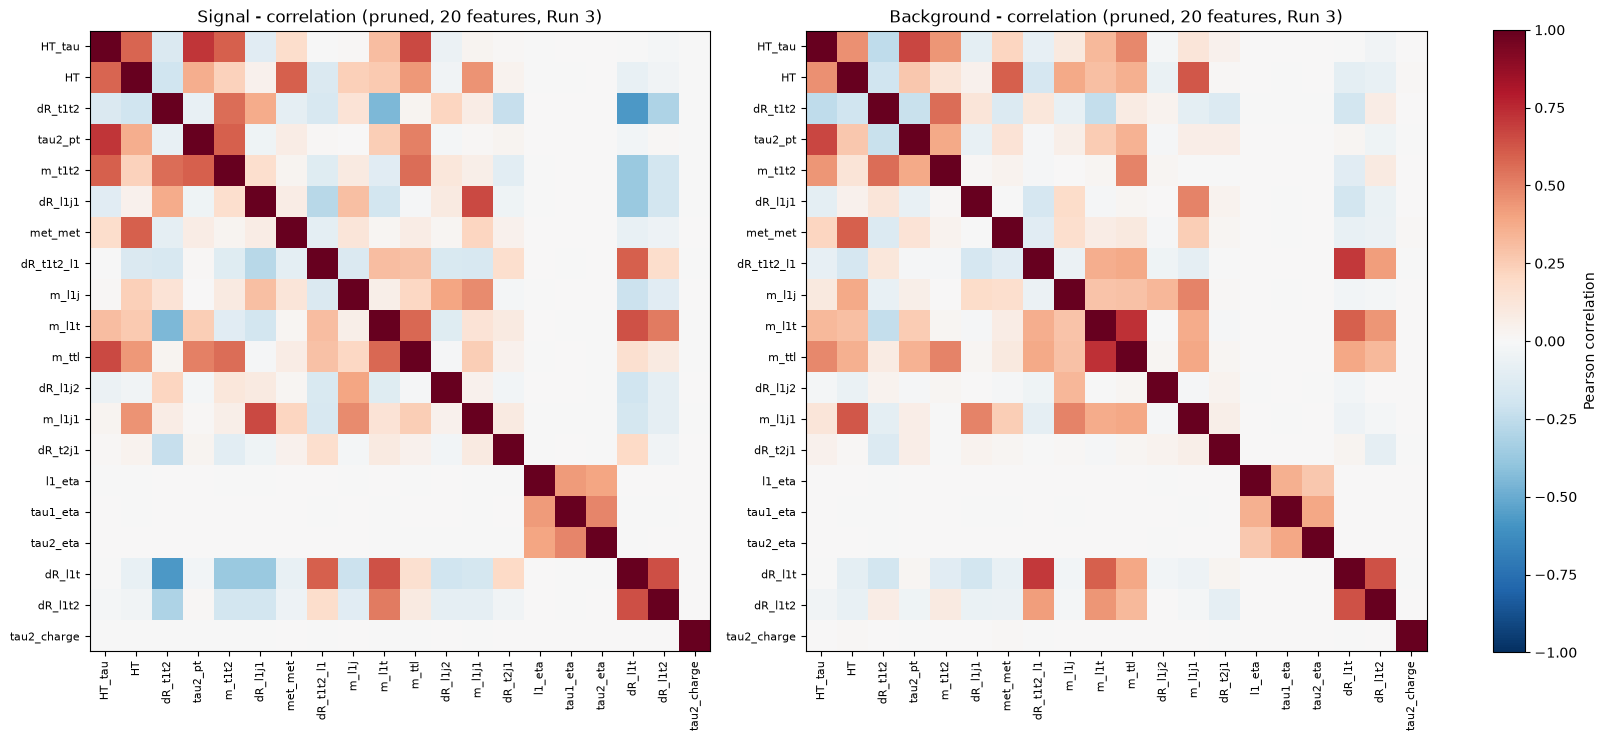

Pairs with |corr| > 0.75 (signal):
Series([], )

Pairs with |corr| > 0.75 (background):
Series([], )


In [63]:
# --- Correlation of the pruned feature set, ordered by pruned-model importance (Run 3) --
pruned_top_feats_r3 = imp_r3_pruned.index.tolist()

pruned_corr_sig_r3 = data_r3.loc[data_r3.label == 1, pruned_top_feats_r3].corr()
pruned_corr_bkg_r3 = data_r3.loc[data_r3.label == 0, pruned_top_feats_r3].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
for ax, corr, title in [(axes[0], pruned_corr_sig_r3, "Signal"), (axes[1], pruned_corr_bkg_r3, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(pruned_top_feats_r3)))
    ax.set_xticklabels(pruned_top_feats_r3, rotation=90, fontsize=8)
    ax.set_yticks(range(len(pruned_top_feats_r3)))
    ax.set_yticklabels(pruned_top_feats_r3, fontsize=8)
    ax.set_title(f"{title} - correlation (pruned, {len(pruned_top_feats_r3)} features, Run 3)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")
plt.show()

print("Pairs with |corr| > 0.75 (signal):")
print(top_pairs(pruned_corr_sig_r3).to_string())
print("\nPairs with |corr| > 0.75 (background):")
print(top_pairs(pruned_corr_bkg_r3).to_string())

## Optuna (Run 3)

In [54]:
# Tune only on the Run-3 training partition. X_val_r3 remains outside Optuna and
# is evaluated once after choosing the best hyperparameters.
# NOTE: N_TRIALS_R3 hardcoded to 15 (matches Run 2's search) instead of reusing
# the shared N_TRIALS variable, which was found to have drifted to 5.
N_TRIALS_R3 = 15
OPTUNA_FEATURES_R3 = PRUNED_FEATURES_R3.copy()  # decorrelated top-20, not the raw top-30

X_opt_r3 = X_train_r3[OPTUNA_FEATURES_R3].reset_index(drop=True)
y_opt_r3 = y_train_r3.reset_index(drop=True).to_numpy()
w_opt_r3 = np.abs(w_train_r3.reset_index(drop=True).to_numpy())


def objective_r3(trial):
    params = {
        "n_estimators": 1200,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
        "tree_method": "hist",
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "n_jobs": -1,
        "random_state": 42,
    }

    fold_aucs = []
    best_iterations = []
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    for fold, (idx_train, idx_valid) in enumerate(cv.split(X_opt_r3, y_opt_r3)):
        fold_model = xgb.XGBClassifier(**params)
        fold_weights = make_fit_weights(y_opt_r3[idx_train], w_opt_r3[idx_train])

        fold_model.fit(
            X_opt_r3.iloc[idx_train], y_opt_r3[idx_train],
            sample_weight=fold_weights,
            eval_set=[(X_opt_r3.iloc[idx_valid], y_opt_r3[idx_valid])],
            sample_weight_eval_set=[w_opt_r3[idx_valid]],
            verbose=False,
        )

        predictions = fold_model.predict_proba(X_opt_r3.iloc[idx_valid])[:, 1]
        fold_auc = roc_auc_score(
            y_opt_r3[idx_valid], predictions, sample_weight=w_opt_r3[idx_valid]
        )
        fold_aucs.append(fold_auc)
        best_iterations.append(fold_model.best_iteration + 1)

        trial.report(float(np.mean(fold_aucs)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("mean_best_iteration", int(round(np.mean(best_iterations))))
    trial.set_user_attr("fold_aucs", [float(value) for value in fold_aucs])
    return float(np.mean(fold_aucs))


study_r3 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    study_name="xgb_1l2tau_run3_top15",
)
study_r3.optimize(objective_r3, n_trials=N_TRIALS_R3, show_progress_bar=True, gc_after_trial=True)

print(f"\nCompleted trials: {len(study_r3.trials)}")
print(f"Best mean CV AUC: {study_r3.best_value:.5f}")
print(f"Mean best iteration: {study_r3.best_trial.user_attrs['mean_best_iteration']}")
print("Fold AUCs:", study_r3.best_trial.user_attrs["fold_aucs"])
print("Best parameters:")
for name, value in study_r3.best_params.items():
    print(f"  {name}: {value}")

/tmp/ipykernel_72546/2732558687.py:65: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]

[W 2026-07-15 11:29:29,014] Trial 0 failed with parameters: {'learning_rate': 0.047377279007281566, 'max_depth': 8, 'min_child_weight': 17.524101118128137, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 21.76624112345367} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/est3ban3/IFJ_PAN_PROJECT/MVA-Project/venv/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_72546/2732558687.py", line 39, in objective_r3
    fold_model.fit(
    ~~~~~~~~~~~~~~^
        X_opt_r3.iloc[idx_train], y_opt_r3[idx_train],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        verbose=False,
        ^^^^^^^^^^^^^^
    )
    ^
  File "/home/est3ban3/IFJ_PAN_PROJECT/MVA-Project/venv/lib/python3.14/site-packages/xgboost/core.py", line 553, in

KeyboardInterrupt: 

In [ ]:
# --- Final model from Optuna (Run 3) -----------------------------------------
# Use the CV-selected number of trees. Do NOT early-stop on X_val_r3: keeping it
# out of tuning makes its AUC a cleaner final Run-3 holdout estimate.
best_n_estimators_r3 = study_r3.best_trial.user_attrs["mean_best_iteration"]
best_params_r3 = {
    **study_r3.best_params,
    "n_estimators": best_n_estimators_r3,
    "tree_method": "hist",
    "eval_metric": "auc",
    "n_jobs": -1,
    "random_state": 42,
}

final_w_fit_r3 = make_fit_weights(
    y_train_r3.to_numpy(), np.abs(w_train_r3.to_numpy())
)
final_model_r3 = xgb.XGBClassifier(**best_params_r3)
final_model_r3.fit(
    X_train_r3[OPTUNA_FEATURES_R3], y_train_r3,
    sample_weight=final_w_fit_r3,
    verbose=False,
)

pred_train_r3 = final_model_r3.predict_proba(X_train_r3[OPTUNA_FEATURES_R3])[:, 1]
pred_holdout_r3 = final_model_r3.predict_proba(X_val_r3[OPTUNA_FEATURES_R3])[:, 1]
w_holdout_abs_r3 = np.abs(w_val_r3.to_numpy())

auc_train_opt_r3 = roc_auc_score(y_train_r3, pred_train_r3, sample_weight=final_w_fit_r3)
auc_holdout_opt_r3 = roc_auc_score(y_val_r3, pred_holdout_r3, sample_weight=w_holdout_abs_r3)
auc_holdout_unweighted_r3 = roc_auc_score(y_val_r3, pred_holdout_r3)

print(f"Features: {len(OPTUNA_FEATURES_R3)}")
print(f"Trees: {best_n_estimators_r3}")
print(f"Weighted AUC train:       {auc_train_opt_r3:.5f}")
print(f"Weighted AUC Run-3 holdout: {auc_holdout_opt_r3:.5f}")
print(f"Unweighted AUC holdout:   {auc_holdout_unweighted_r3:.5f}")
print(f"Overtraining gap:         {auc_train_opt_r3 - auc_holdout_opt_r3:.5f}")

In [ ]:
# --- Optuna diagnostics and holdout ROC (Run 3) ------------------------------
trials_r3 = study_r3.trials_dataframe()
complete_r3 = trials_r3.loc[trials_r3["state"] == "COMPLETE"].copy()
param_importance_r3 = optuna.importance.get_param_importances(study_r3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

axes[0].plot(complete_r3["number"], complete_r3["value"], "o", alpha=0.7)
axes[0].plot(
    complete_r3["number"], complete_r3["value"].cummax(),
    color="black", linewidth=2, label="best so far"
)
axes[0].set(xlabel="Trial", ylabel="Mean 3-fold AUC", title="Optuna history (Run 3)")
axes[0].legend()

names_r3 = list(param_importance_r3)
values_r3 = [param_importance_r3[name] for name in names_r3]
axes[1].barh(names_r3[::-1], values_r3[::-1], color="steelblue")
axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

fpr_r3, tpr_r3, _ = roc_curve(
    y_val_r3, pred_holdout_r3, sample_weight=w_holdout_abs_r3
)
axes[2].plot(fpr_r3, tpr_r3, linewidth=2, label=f"AUC = {auc_holdout_opt_r3:.4f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray")
axes[2].set(
    xlabel="False-positive rate", ylabel="True-positive rate",
    title="Run-3 holdout ROC", xlim=(0, 1), ylim=(0, 1)
)
axes[2].legend(loc="lower right")
plt.show()

print("Final Optuna features (Run 3):")
print(OPTUNA_FEATURES_R3)

## Optuna-tuned model — feature importance & correlation (Run 3)

In [ ]:
# --- Feature importance of the Optuna-tuned final model (Run 3) -------------
final_booster_r3 = final_model_r3.get_booster()

final_imp_r3 = pd.DataFrame({
    t: final_booster_r3.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(OPTUNA_FEATURES_R3).fillna(0.0)

final_imp_r3 = final_imp_r3.sort_values("total_gain", ascending=False)
final_imp_r3["gain_frac"] = final_imp_r3["total_gain"] / final_imp_r3["total_gain"].sum()

print("Optuna-tuned model — feature importance by total gain (Run 3):")
print(final_imp_r3[["total_gain", "gain_frac", "weight"]].to_string())
print(f"\nFeatures never used in a split: {(final_imp_r3['total_gain'] == 0).sum()} / {len(OPTUNA_FEATURES_R3)}")

fig, ax = plt.subplots(figsize=(8, 8))
final_imp_r3["gain_frac"][::-1].plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance — Optuna-tuned model ({len(OPTUNA_FEATURES_R3)} features, 1l2tau, Run 3)")
plt.tight_layout()
plt.show()

In [ ]:
# --- Correlation of features, ordered by Optuna-tuned model importance (Run 3) --
final_top_feats_r3 = final_imp_r3.index.tolist()

final_corr_sig_r3 = data_r3.loc[data_r3.label == 1, final_top_feats_r3].corr()
final_corr_bkg_r3 = data_r3.loc[data_r3.label == 0, final_top_feats_r3].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
for ax, corr, title in [(axes[0], final_corr_sig_r3, "Signal"), (axes[1], final_corr_bkg_r3, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(final_top_feats_r3)))
    ax.set_xticklabels(final_top_feats_r3, rotation=90, fontsize=7)
    ax.set_yticks(range(len(final_top_feats_r3)))
    ax.set_yticklabels(final_top_feats_r3, fontsize=7)
    ax.set_title(f"{title} — correlation (Optuna-tuned, {len(final_top_feats_r3)} features, Run 3)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")
plt.show()

print("Pairs with |corr| > 0.9 (signal):")
print(top_pairs(final_corr_sig_r3).to_string())
print("\nPairs with |corr| > 0.9 (background):")
print(top_pairs(final_corr_bkg_r3).to_string())